In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

import sys


from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure2 import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

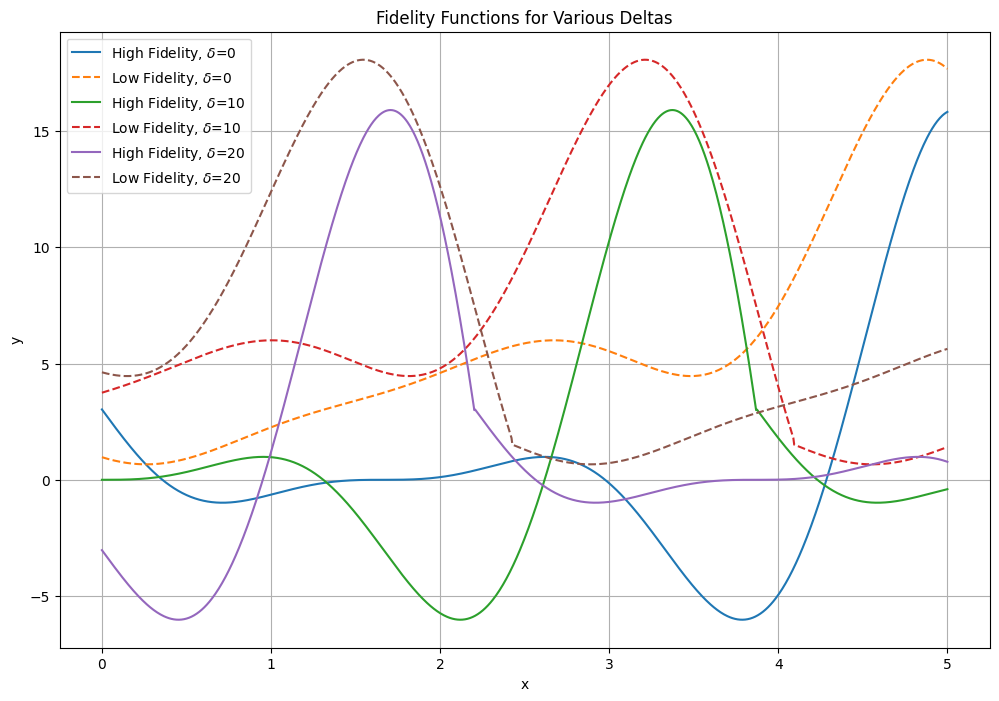

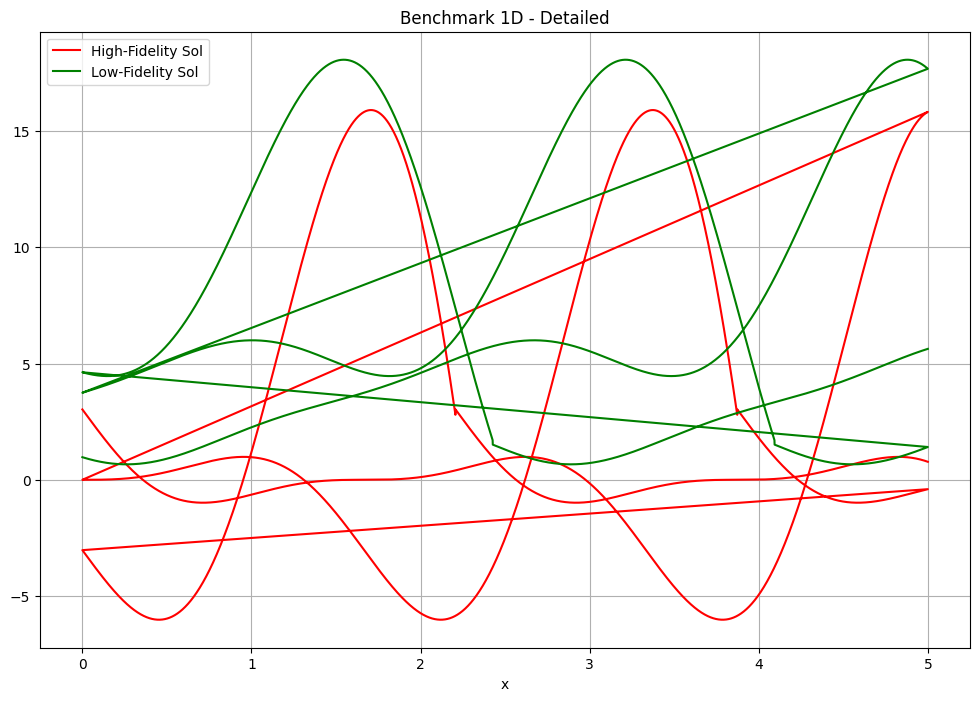

In [2]:
example = "Basic"
fidelity_func = FidelityFunctionModified(example)
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()

In [3]:
data=fidelity_func.get_parameters(example)

In [4]:
data

{'modified_highfid': CPUDispatcher(<function FidelityFunctionModified.create_basic_functions.<locals>.modified_highfid at 0x000001C488CBB420>),
 'modified_lowfid': CPUDispatcher(<function FidelityFunctionModified.create_basic_functions.<locals>.modified_lowfid at 0x000001C488CBB380>),
 'Nhf': 50,
 'Nlf': 100,
 'xhf': array([[ 0.        ,  0.        ],
        [ 0.10204082,  0.        ],
        [ 0.20408163,  0.        ],
        [ 0.30612245,  0.        ],
        [ 0.40816327,  0.        ],
        [ 0.51020408,  0.        ],
        [ 0.6122449 ,  0.        ],
        [ 0.71428571,  0.        ],
        [ 0.81632653,  0.        ],
        [ 0.91836735,  0.        ],
        [ 1.02040816,  0.        ],
        [ 1.12244898,  0.        ],
        [ 1.2244898 ,  0.        ],
        [ 1.32653061,  0.        ],
        [ 1.42857143,  0.        ],
        [ 1.53061224,  0.        ],
        [ 1.63265306,  0.        ],
        [ 1.73469388,  0.        ],
        [ 1.83673469,  0.        ]

Function training took 9.3346 seconds
The function training took 9.334602117538452 seconds.


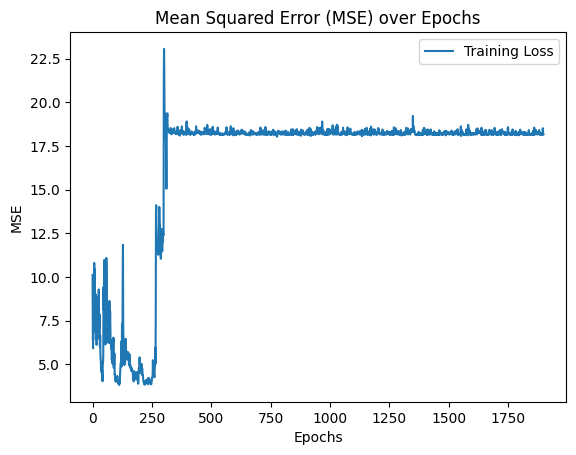

Test MSE: 54.50092175825764
R^2: -0.8538518624306295


Text(0.5, 1.0, 'Low fidelity model')

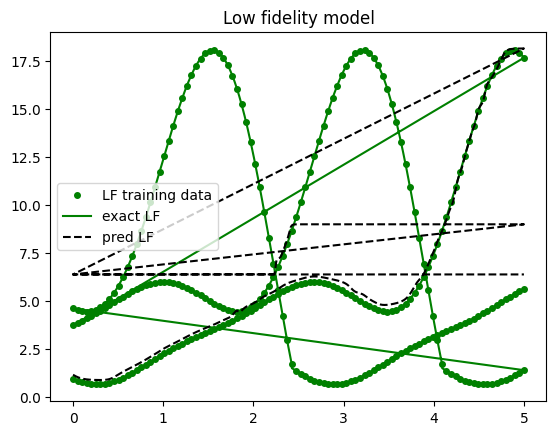

In [5]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_LF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xlf"],
        "output_train": data["Ylf"],
        "N": data["NepoLF"],
        "n": data["Nlf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
# building of the neural network
modelLF=NetworkFactory.build_network(**definition_LF)
# prediction step
yLF=modelLF.prediction(data["datatest"])
(mse_LF,R2_LF)=modelLF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xlf"][:,0],data["Ylf"],'go', label = 'LF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_lowfid"](data["datatest"][:,0],data["datatest"][:,1]),'g', label = 'exact LF') 
plt.plot(data["datatest"][:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

Function training took 7.9871 seconds
The function training took 7.98824143409729 seconds.


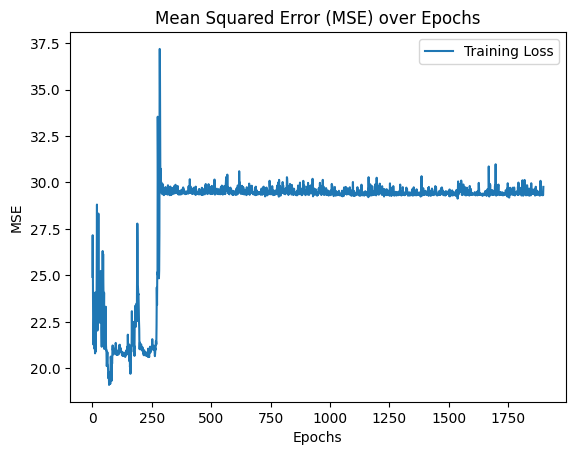

Test MSE: 29.056235078628685
R^2: 0.011650559697615748


Text(0.5, 1.0, 'High fidelity model')

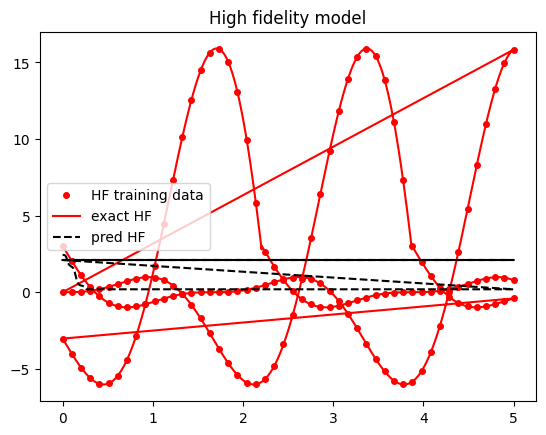

In [6]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_HF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xhf"],
        "output_train": data["Yhf"],
        "N": data["NepoHF"],
        "n": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
modelHF=NetworkFactory.build_network(**definition_HF)
yHF=modelHF.prediction(data["datatest"])
(mse_HF,R2_HF)=modelHF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],yHF,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')



Function training took 9.2748 seconds
The function training took 9.274814128875732 seconds.


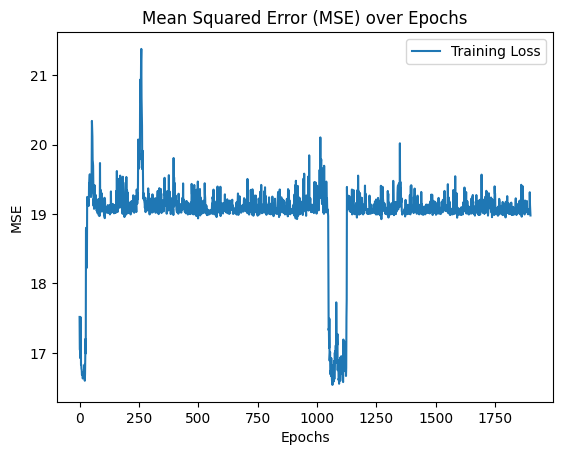

Function training took 6.5826 seconds
The function training took 6.583640813827515 seconds.


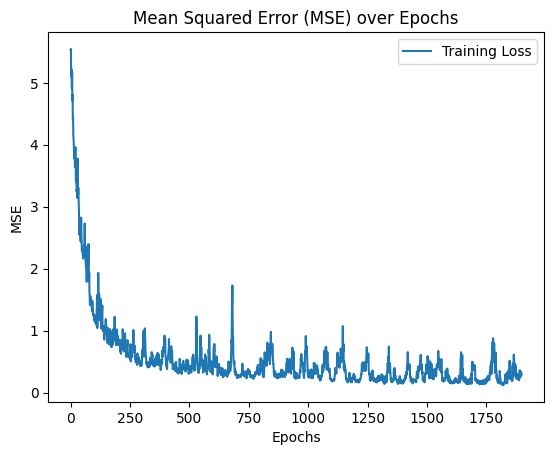

Test MSE: 0.10245065792981596
R^2: 0.9965151352145406


Text(0.5, 1.0, 'High fidelity model')

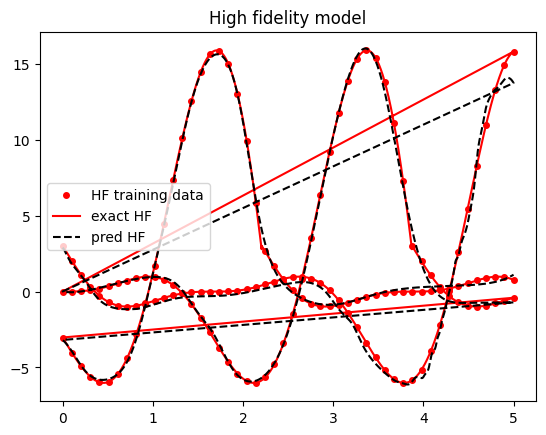

In [7]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)

if final_model == -1:
    raise ValueError("Failed to build the network. Check the network type and parameters.")

y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


In [8]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)

if final_model == -1:
    raise ValueError("Failed to build the network. Check the network type and parameters.")

y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


[I 2024-07-27 19:12:56,657] A new study created in memory with name: no-name-d7e23e76-669d-49ed-a280-07ed312af5c4


1/1 [==============================] - 0s 21ms/step


[I 2024-07-27 18:28:05,345] A new study created in memory with name: no-name-c4a2f01e-6f22-45ad-a9d7-a61203ba3206
c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\prova_1d\../utils\Structure2.py:837: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2weight": trial.suggest_loguniform("l2weight", 1e-4, 1e-1),
c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\prova_1d\../utils\Structure2.py:838: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "lr": trial.suggest_loguniform("lr", 1e-4, 1e-1),


1/1 [==============================] - 0s 20ms/step


[I 2024-07-27 18:53:10,021] Trial 1 finished with value: 0.03223672208694988 and parameters: {'nodes': 28, 'l2weight': 0.0004320118266036643, 'lr': 0.01426214976310544, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.03223672208694988.


1/1 [==============================] - 0s 18ms/step


[I 2024-07-27 18:53:13,471] Trial 0 finished with value: 0.005049461349130826 and parameters: {'nodes': 39, 'l2weight': 0.00046196980514932786, 'lr': 0.00010614338788929339, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.005049461349130826.


Function training took 9.9928 seconds
The function training took 9.992815732955933 seconds.


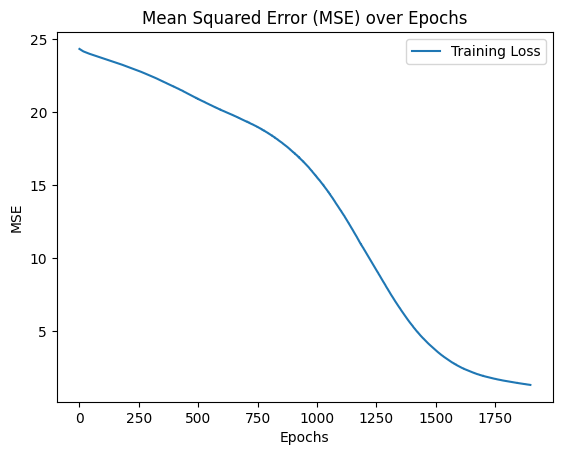

[I 2024-07-27 18:53:23,706] A new study created in memory with name: no-name-2bd42cc8-2ab5-431c-8923-790968cd7472


1/1 [==============================] - 0s 22ms/step


[I 2024-07-27 19:02:57,680] Trial 1 finished with value: 0.8987608470307513 and parameters: {'nodes': 8, 'l2weight': 0.0010310987454560598, 'lr': 0.0024370984619517286, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.8987608470307513.


1/1 [==============================] - 0s 18ms/step


[I 2024-07-27 19:02:58,036] Trial 0 finished with value: 0.08465824464536457 and parameters: {'nodes': 18, 'l2weight': 0.005641929151186221, 'lr': 0.030107815965594274, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.08465824464536457.


Function training took 7.5259 seconds
The function training took 7.525943994522095 seconds.


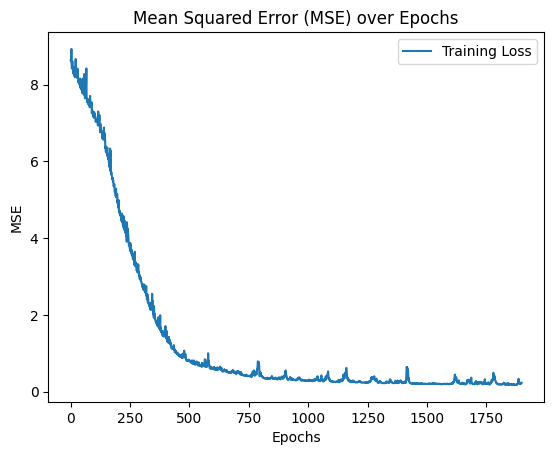

Test MSE: 0.08557046346571333
R^2: 0.9970893159611391


Text(0.5, 1.0, 'High fidelity model')

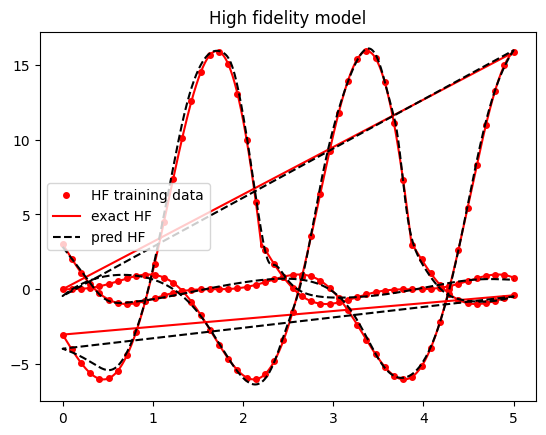

In [10]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)

if final_model == -1:
    raise ValueError("Failed to build the network. Check the network type and parameters.")

y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


# Prediction of a parameter 2 step nn

In [ ]:
deltas=np.array([0,10,20])

Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 1/3000 [00:00<06:15,  8.00it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.27: 100%|██████████| 3000/3000 [05:01<00:00,  9.95it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [05:03<00:00,  9.89it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.027]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.027  0.029   9.966   10.076      0.002    0.001     298.0     211.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.027]



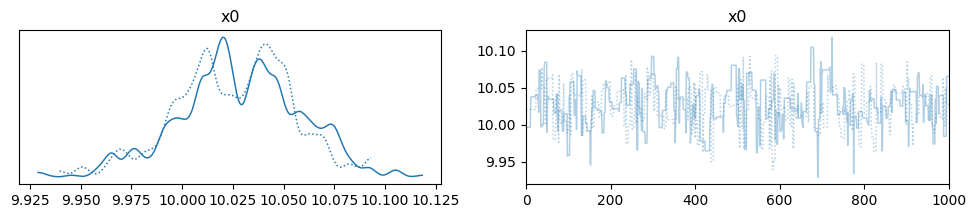

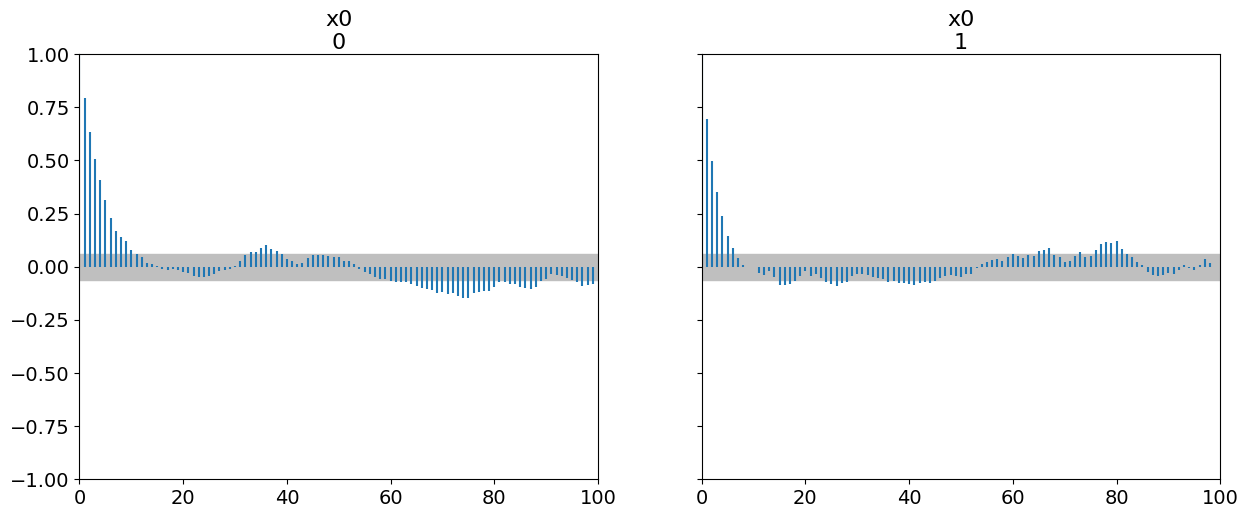

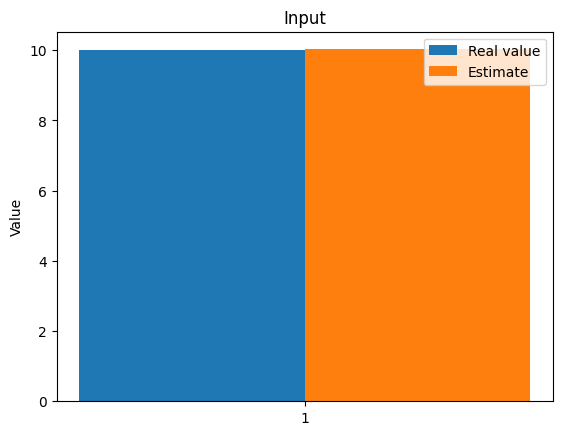

The function param_inverse took 617.6386342048645 seconds.
Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/3000 [00:00<?, ?it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.33: 100%|██████████| 3000/3000 [05:00<00:00,  9.97it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:57<00:00, 10.09it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.022]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.022  0.03   9.972   10.076      0.002    0.001     400.0     329.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.022]



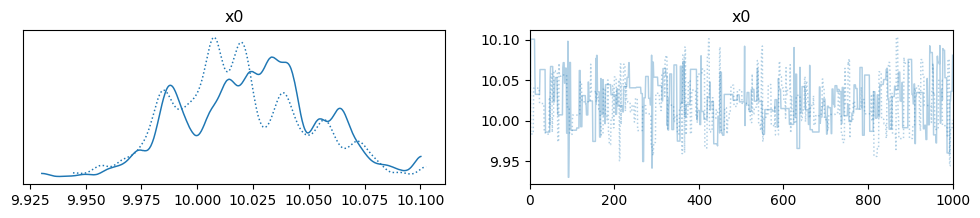

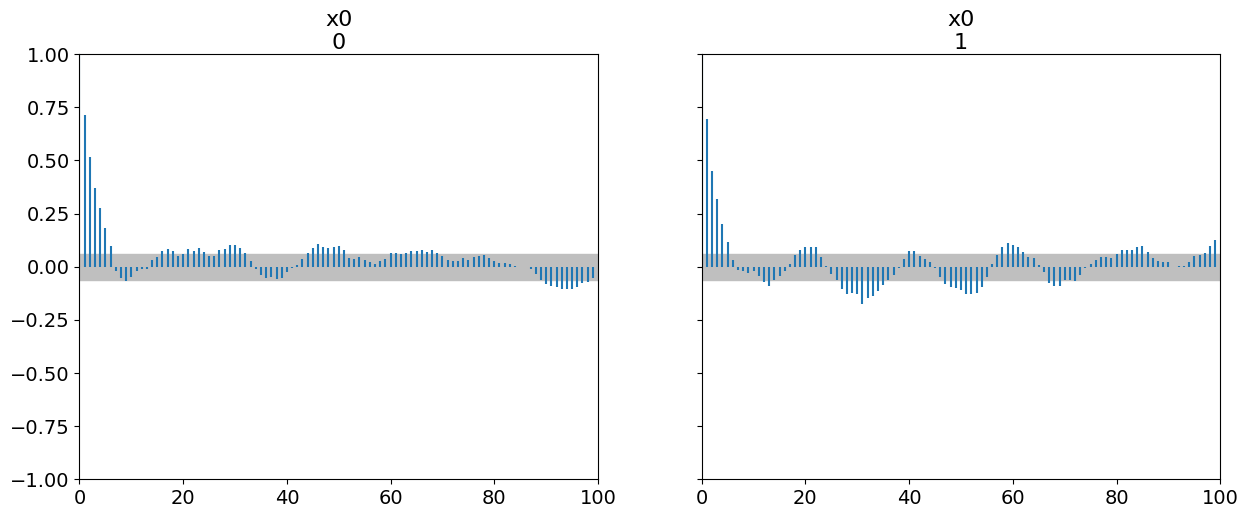

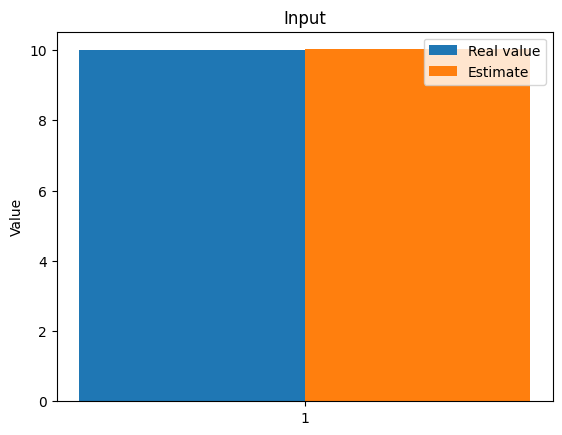

The function param_inverse took 612.5126416683197 seconds.
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:59<00:00, 10.03it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [04:54<00:00, 10.18it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [9.974]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.974  0.118   9.776   10.207      0.007    0.005     332.0     399.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.026]



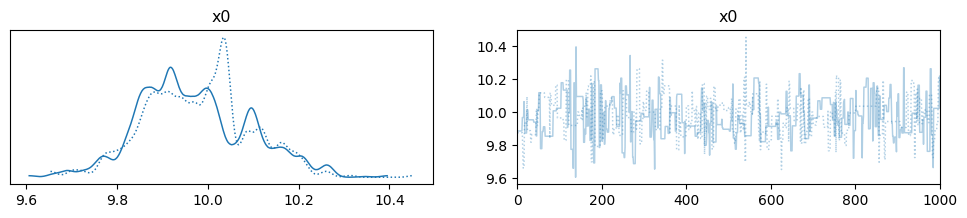

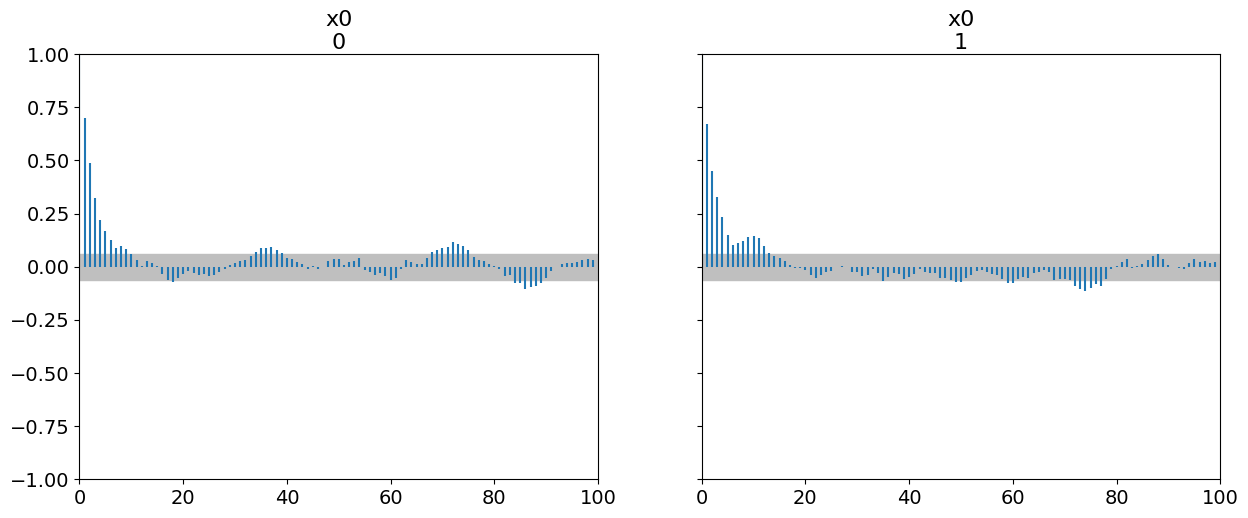

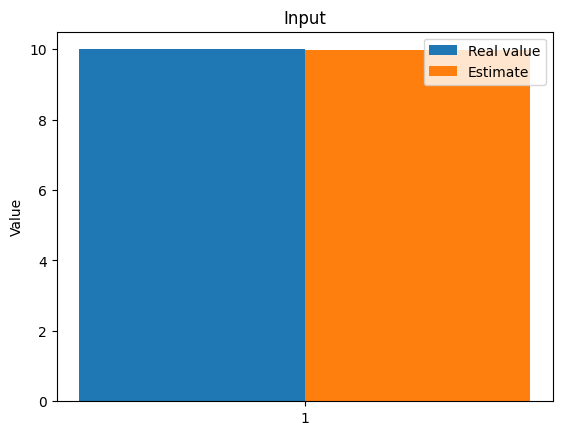

The function param_inverse took 594.9808623790741 seconds.
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [05:01<00:00,  9.96it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [05:00<00:00,  9.98it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [9.988]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.988  0.123   9.765   10.218      0.007    0.005     299.0     300.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.012]



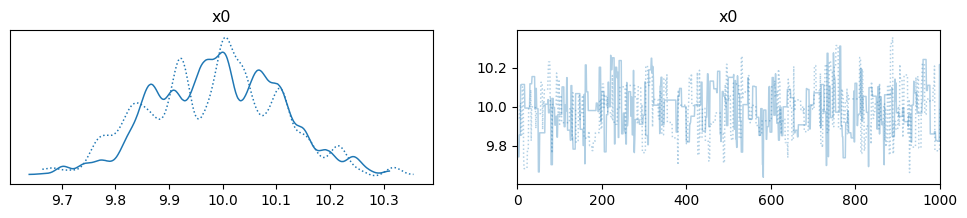

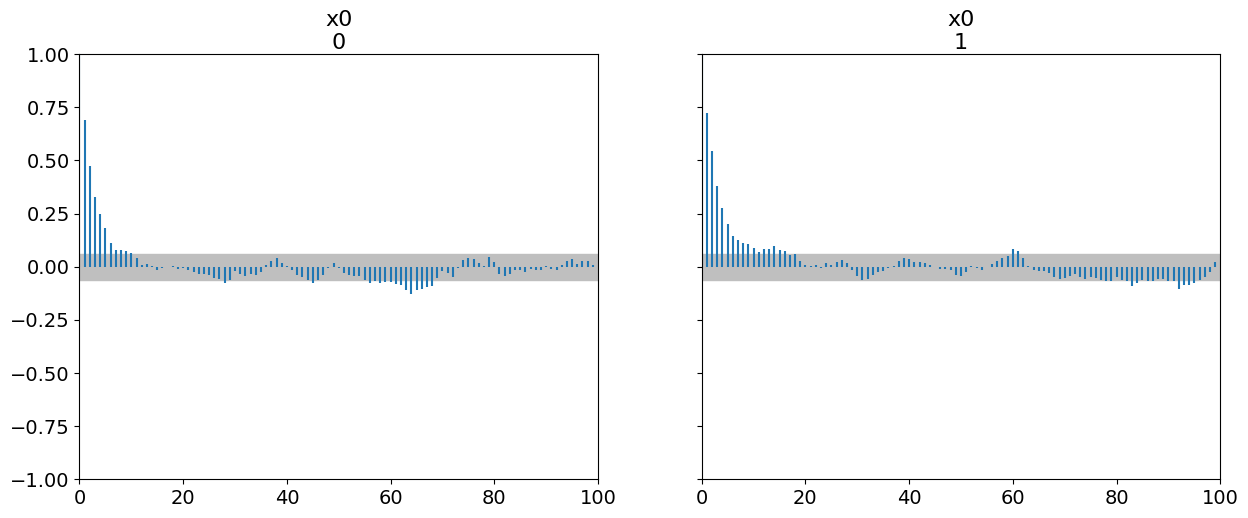

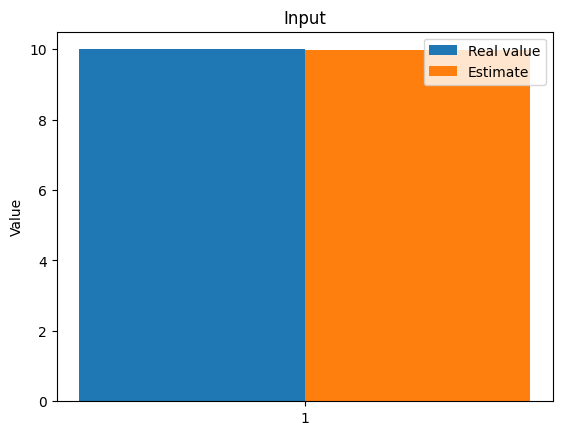

The function param_inverse took 603.2753512859344 seconds.
Sampling chain 1/2


Running chain, α = 0.20:   0%|          | 4/3000 [00:00<04:34, 10.93it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:42<00:00, 10.62it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:47<00:00, 10.43it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.097]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.097  0.037  10.025   10.162      0.002    0.002     303.0     336.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.097]



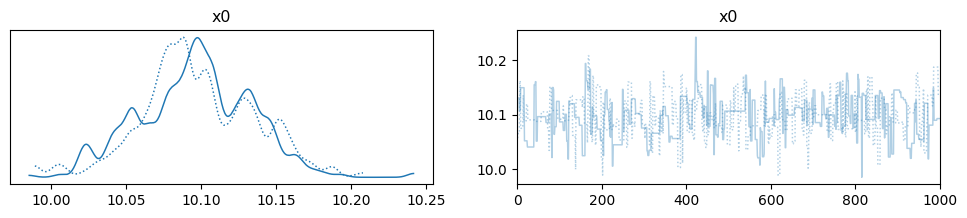

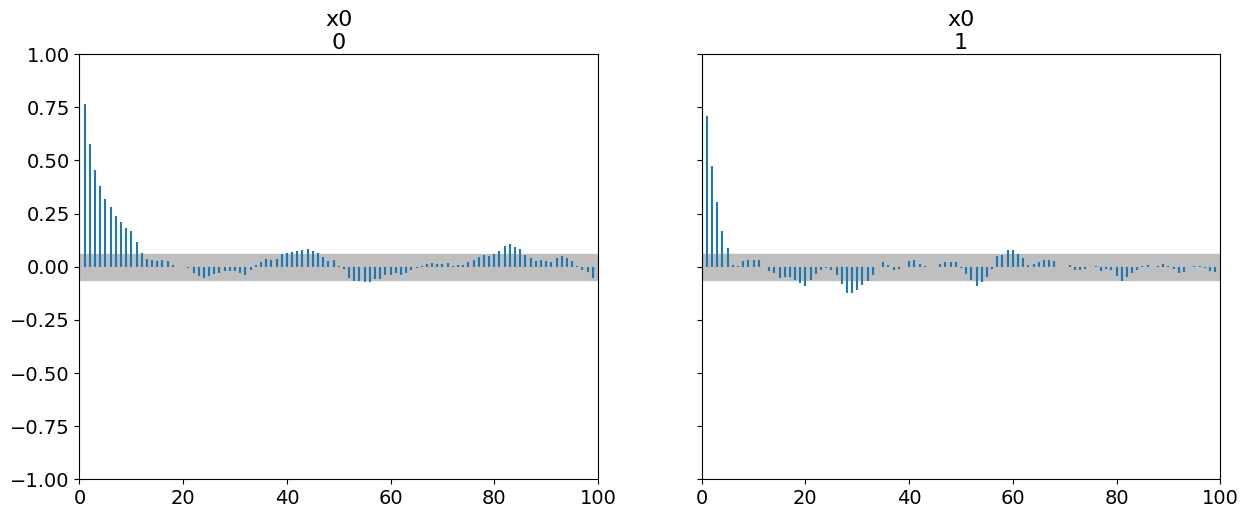

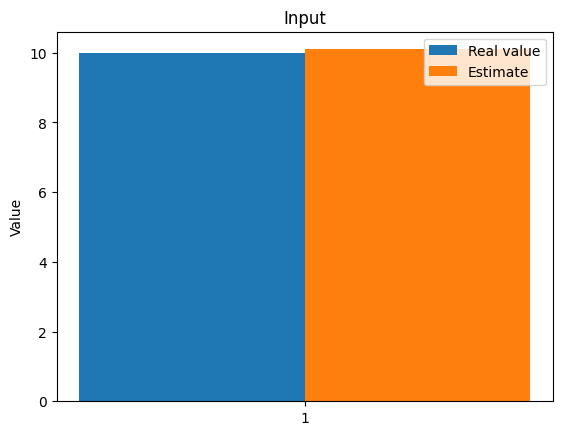

The function param_inverse took 584.6626951694489 seconds.
Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 2/3000 [00:00<04:51, 10.29it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:47<00:00, 10.43it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:47<00:00, 10.44it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.104]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.104  0.038  10.038   10.176      0.002    0.002     283.0     344.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.104]



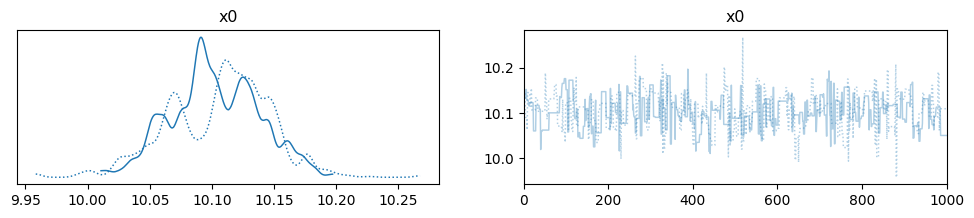

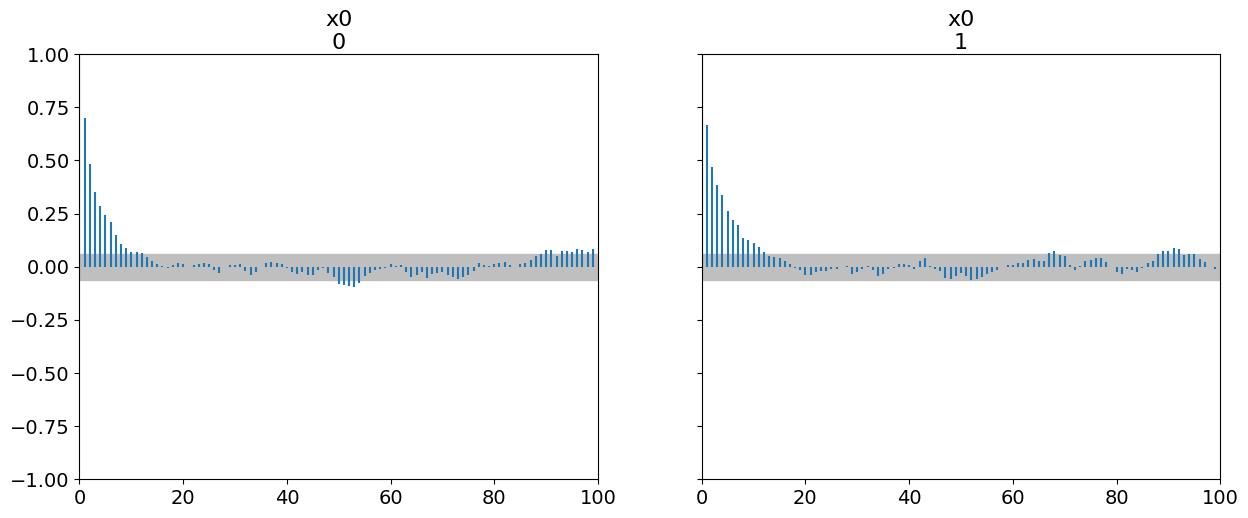

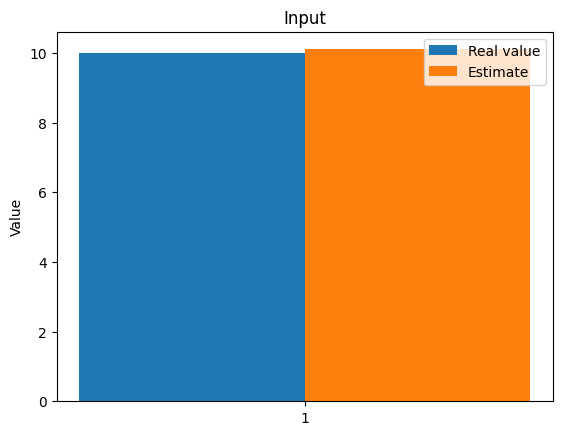

The function param_inverse took 576.2403428554535 seconds.
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:47<00:00, 10.44it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:47<00:00, 10.43it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.048]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.048  0.149   9.768    10.31      0.008    0.006     335.0     276.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.048]



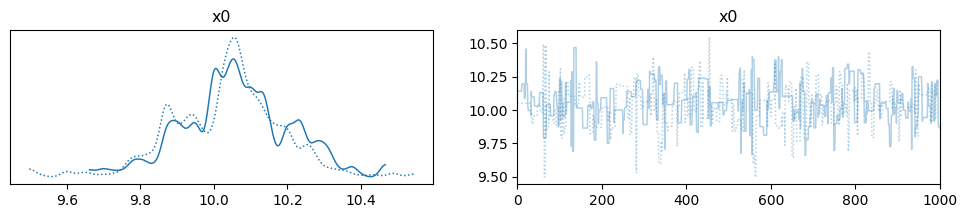

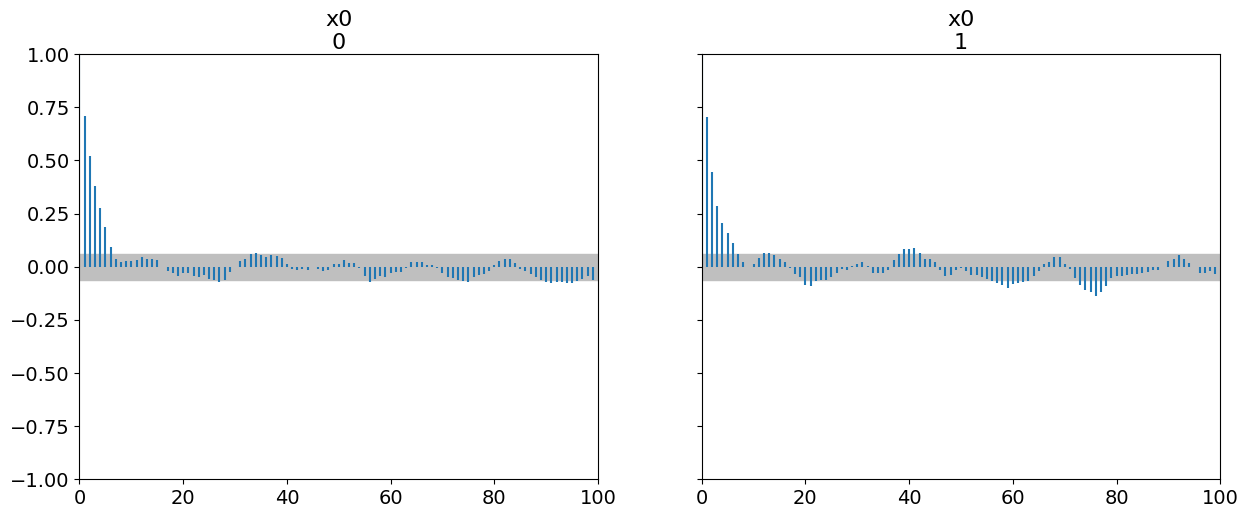

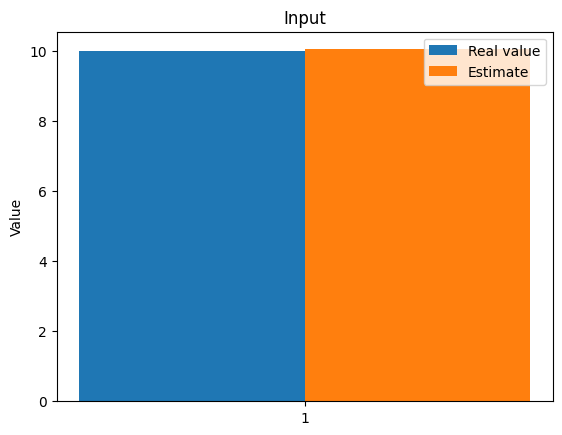

The function param_inverse took 576.1742725372314 seconds.
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:48<00:00, 10.41it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:47<00:00, 10.43it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.016]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.016  0.16   9.737   10.328      0.009    0.007     291.0     338.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.016]



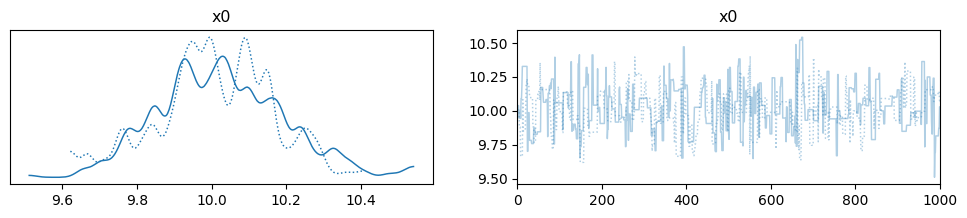

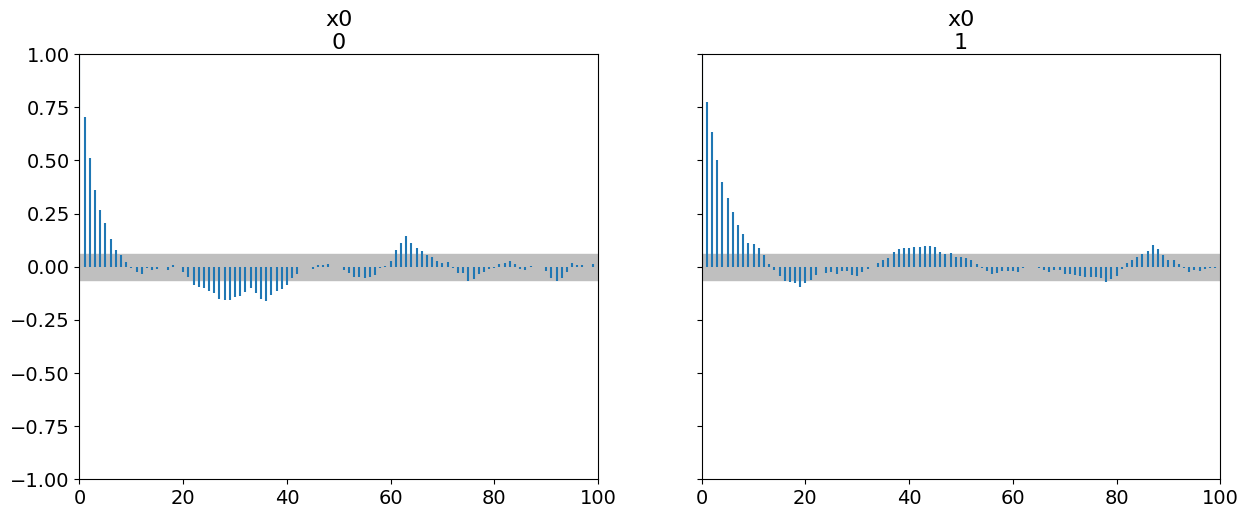

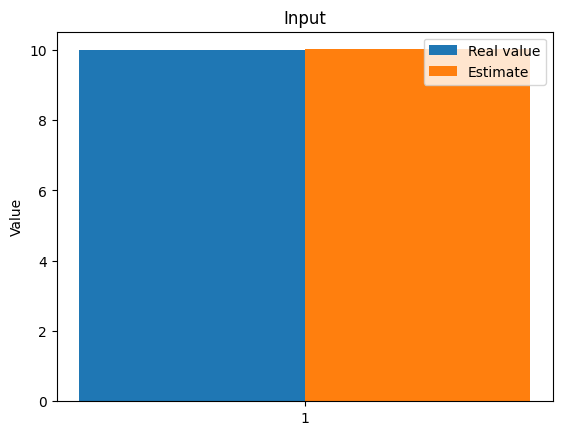

The function param_inverse took 588.6070048809052 seconds.
Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/3000 [00:00<?, ?it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.27: 100%|██████████| 3000/3000 [05:02<00:00,  9.93it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [05:01<00:00,  9.96it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.017]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.017  0.031   9.957    10.07      0.002    0.001     308.0     235.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.017]



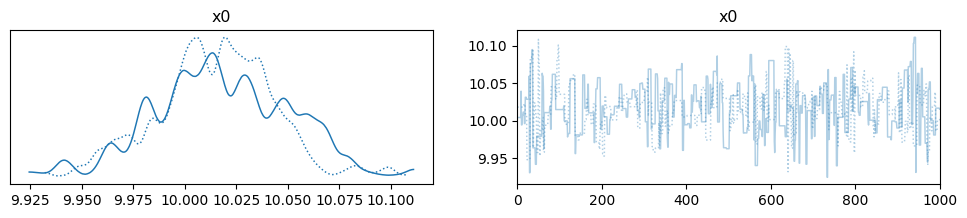

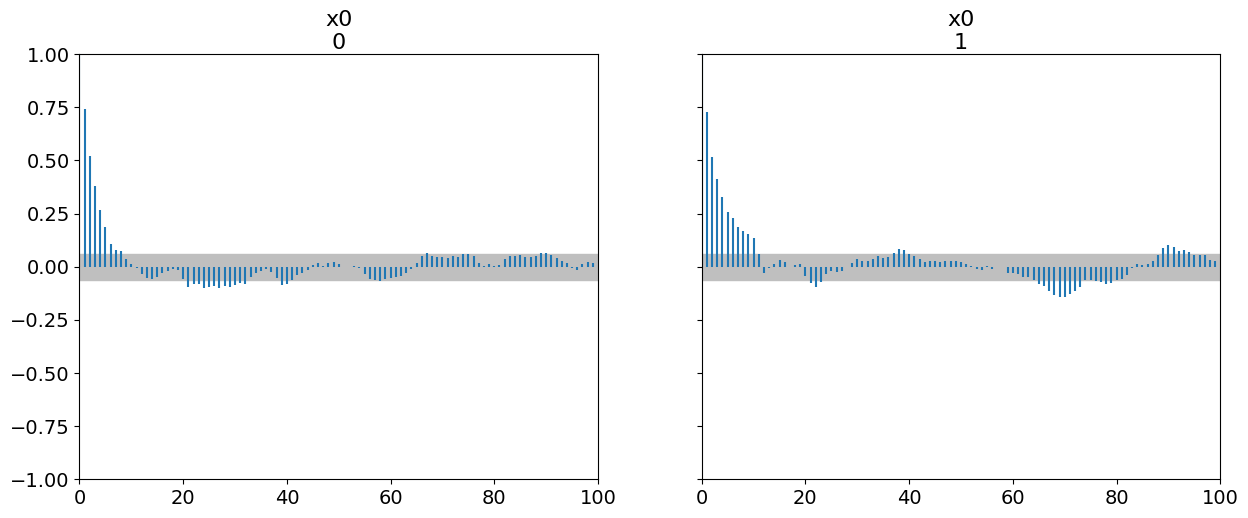

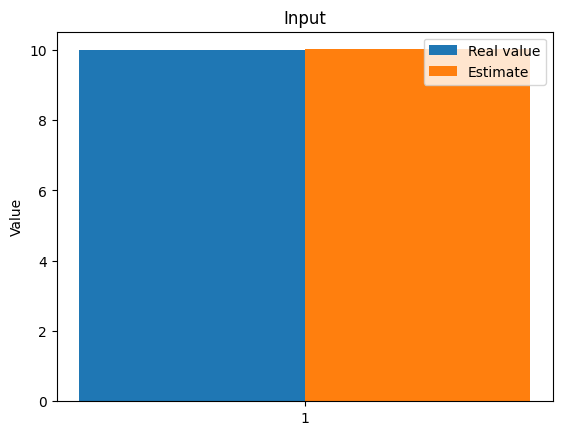

The function param_inverse took 617.3872842788696 seconds.
Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/3000 [00:00<?, ?it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.22: 100%|██████████| 3000/3000 [05:01<00:00,  9.94it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [05:24<00:00,  9.23it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.022]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.022  0.026   9.975   10.066      0.001    0.001     349.0     269.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.022]



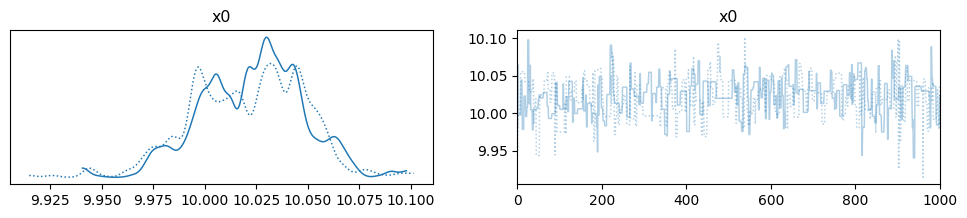

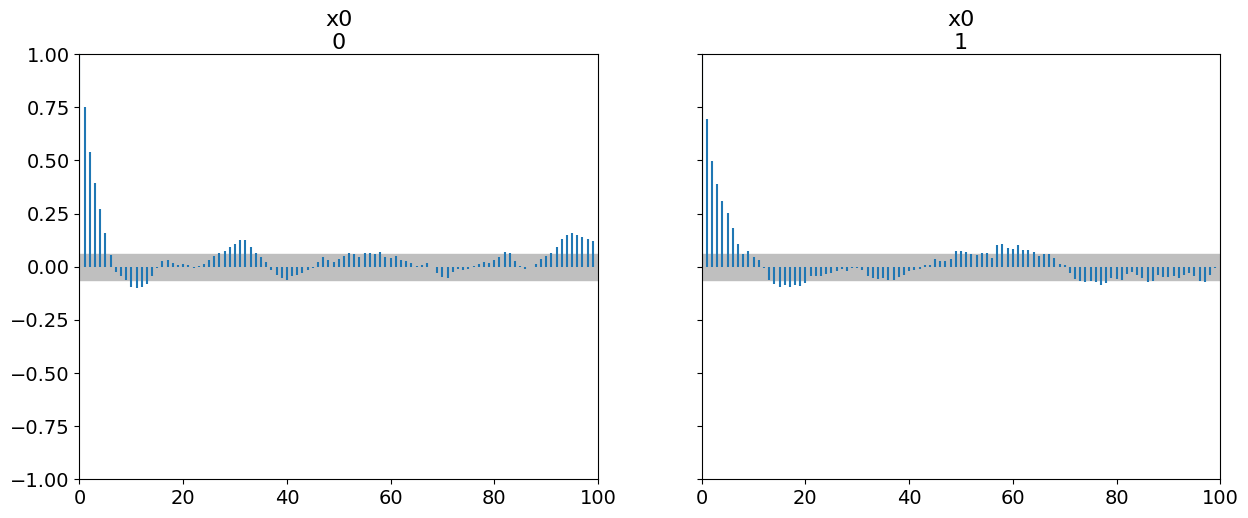

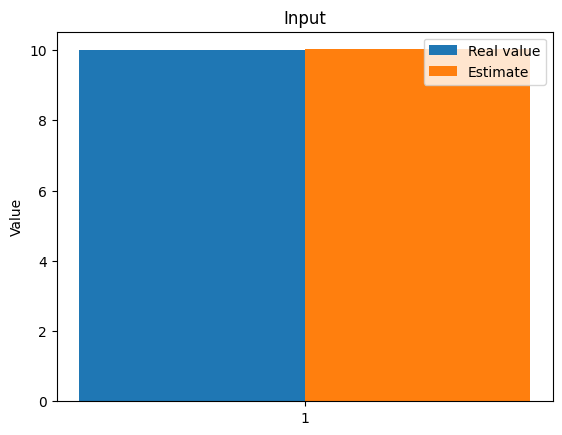

The function param_inverse took 628.0899951457977 seconds.
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [05:13<00:00,  9.57it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [05:12<00:00,  9.60it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [9.977]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.977  0.112   9.759    10.17      0.006    0.004     319.0     349.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.023]



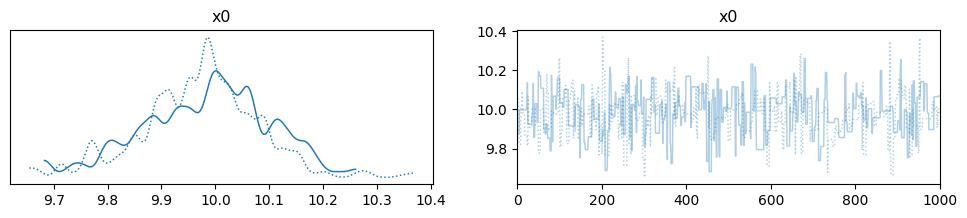

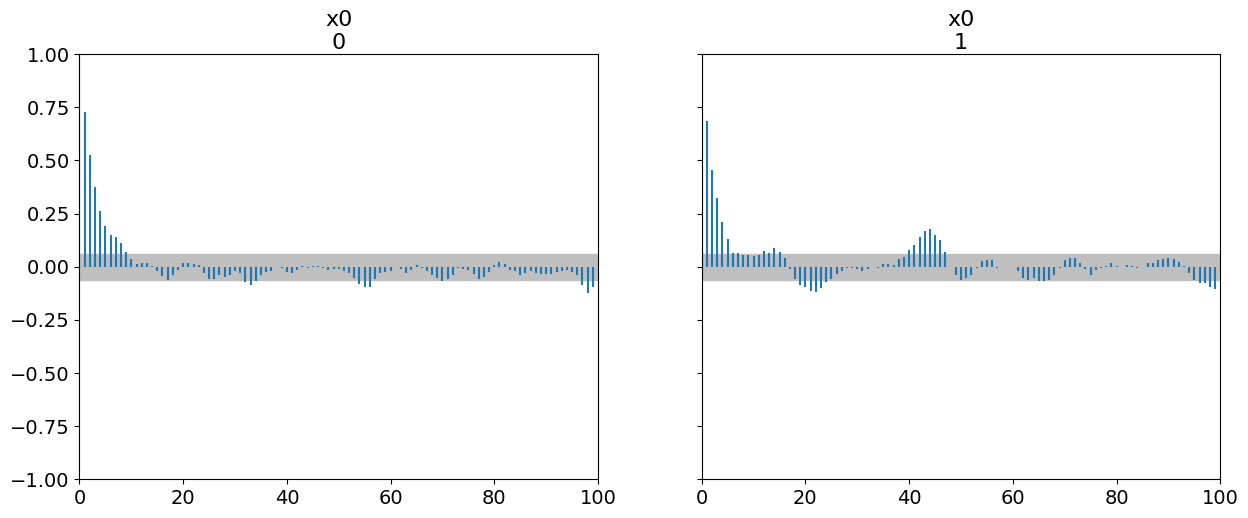

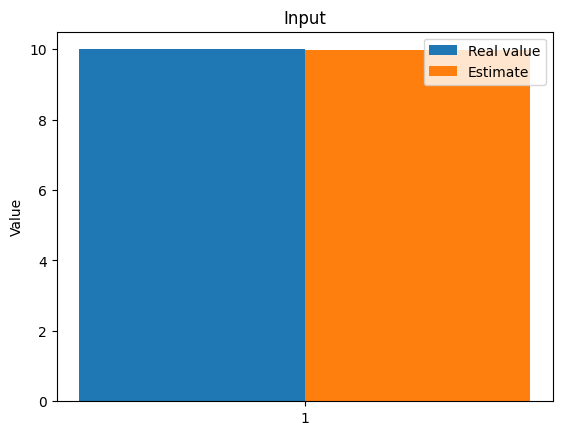

The function param_inverse took 627.4220895767212 seconds.
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:13<00:00,  9.56it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [05:13<00:00,  9.58it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [9.964]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.964  0.117   9.772   10.199      0.006    0.005     327.0     312.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.036]



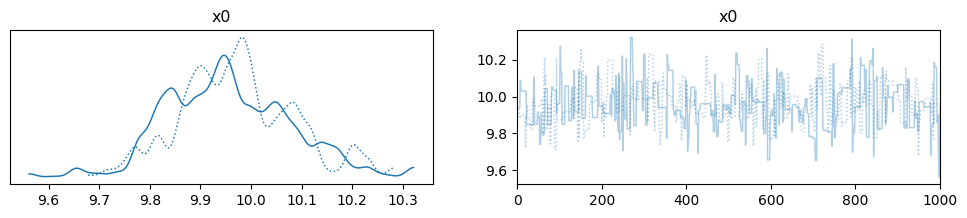

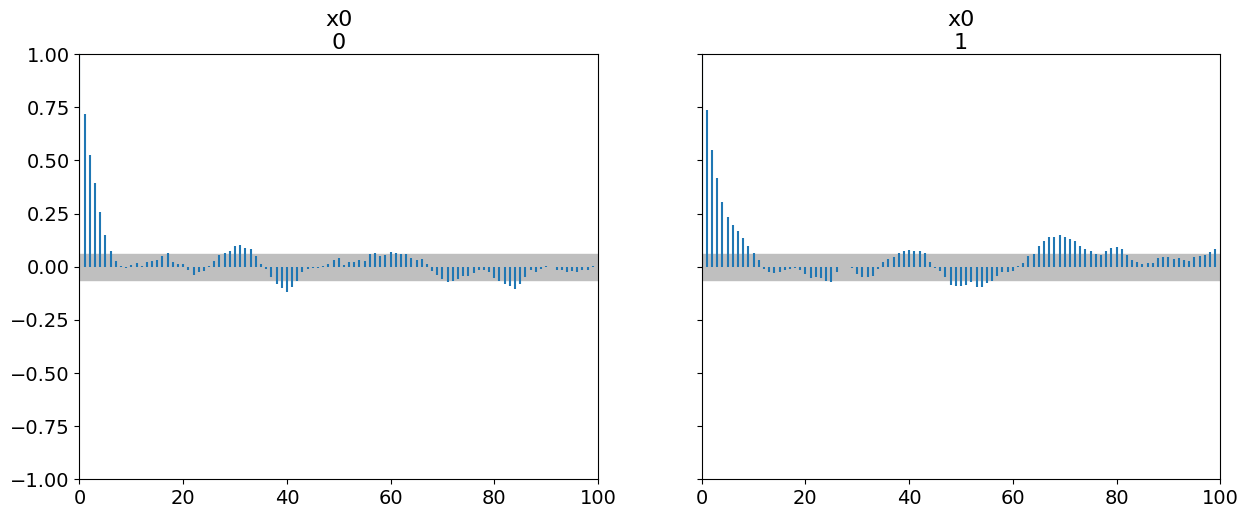

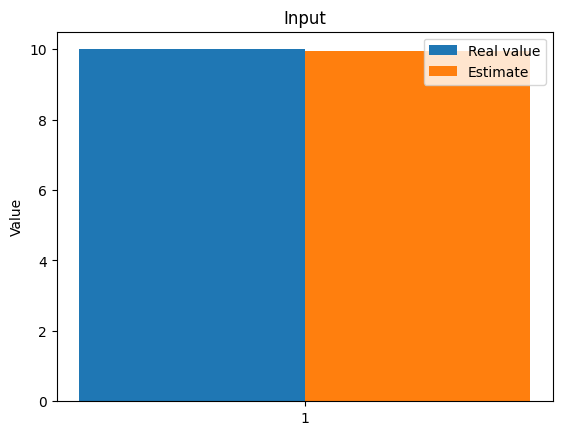

The function param_inverse took 628.3367621898651 seconds.
Sampling chain 1/2


Running chain, α = 0.29: 100%|██████████| 3000/3000 [04:57<00:00, 10.07it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:59<00:00, 10.01it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.092]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.092  0.037  10.022   10.159      0.002    0.001     342.0     320.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.092]



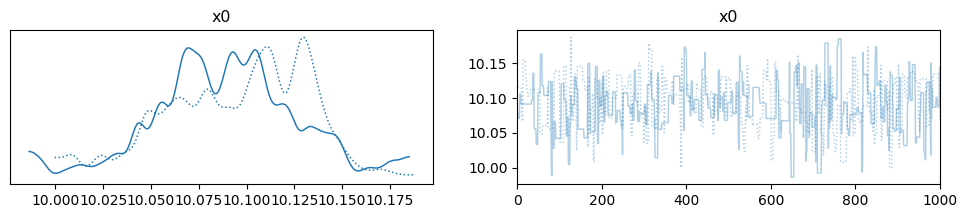

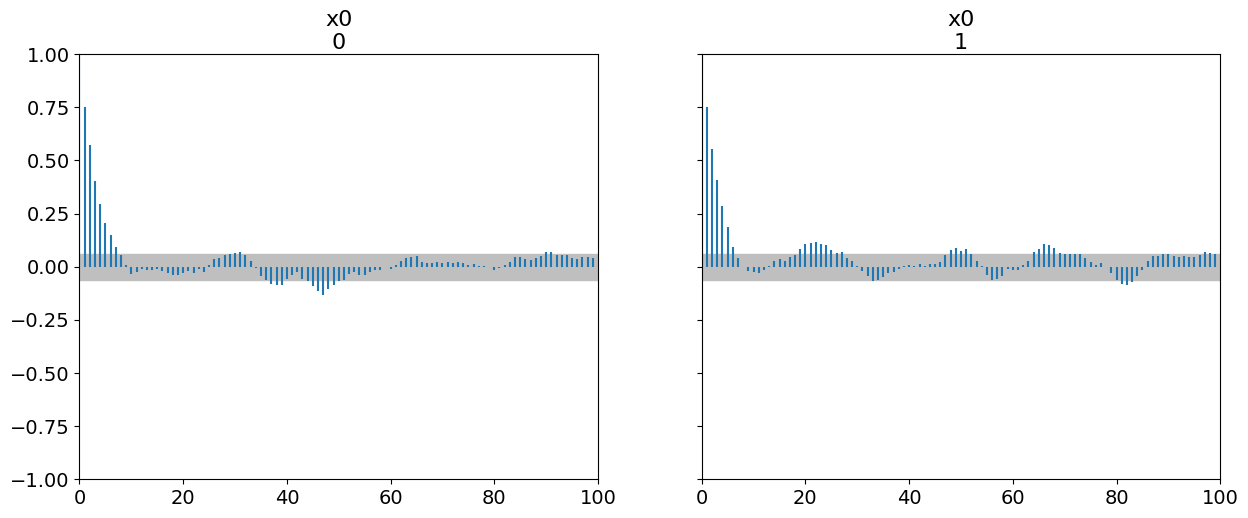

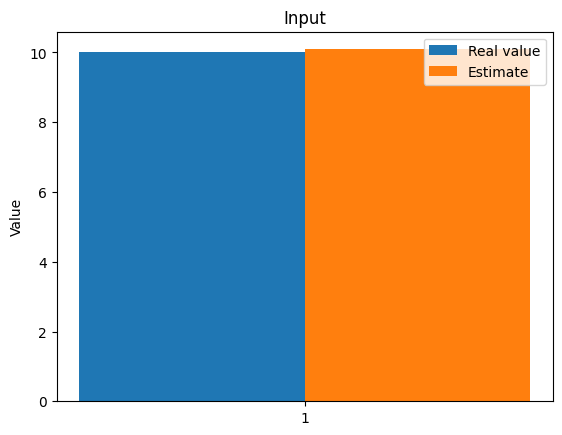

The function param_inverse took 612.5969524383545 seconds.
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:57<00:00, 10.10it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:59<00:00, 10.00it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.091]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.091  0.035  10.028   10.157      0.002    0.001     369.0     277.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.091]



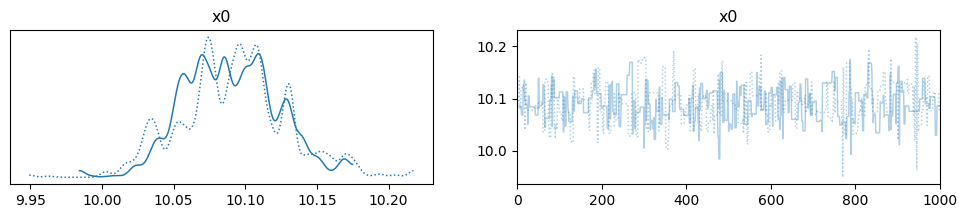

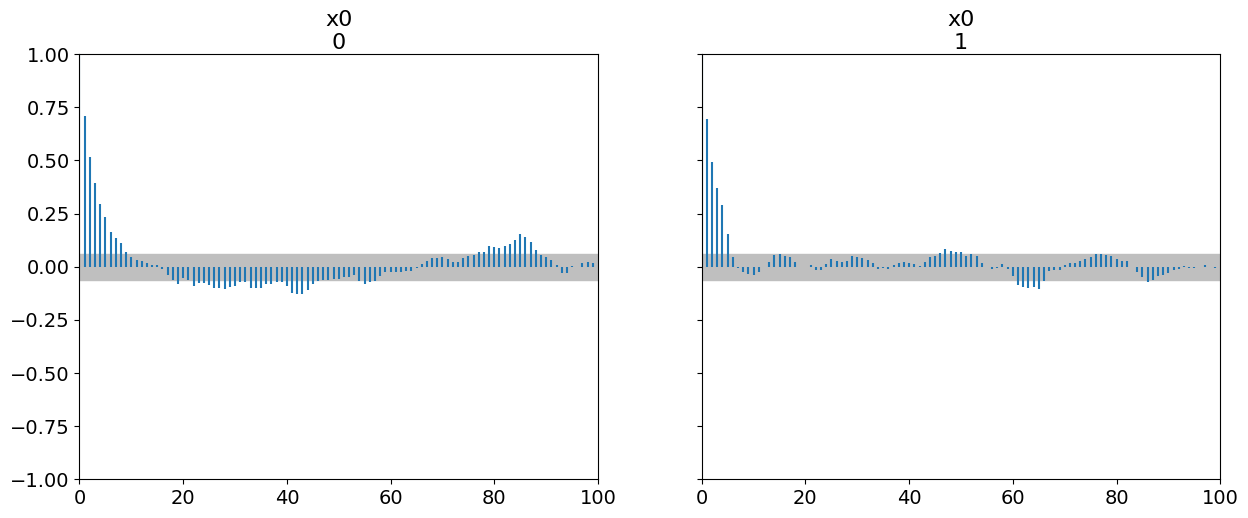

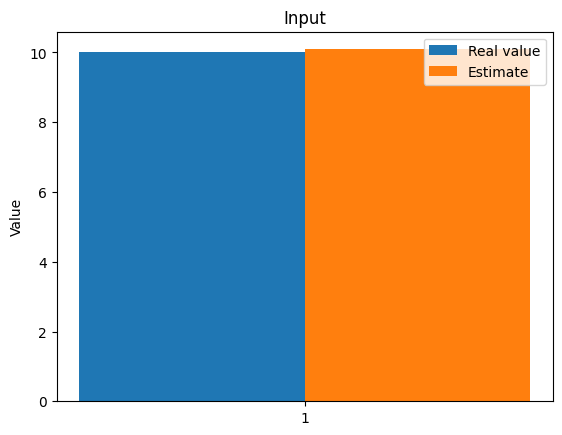

The function param_inverse took 613.7015826702118 seconds.
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:58<00:00, 10.06it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [04:58<00:00, 10.06it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.034]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.034  0.146   9.788   10.341      0.008    0.006     304.0     289.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.034]



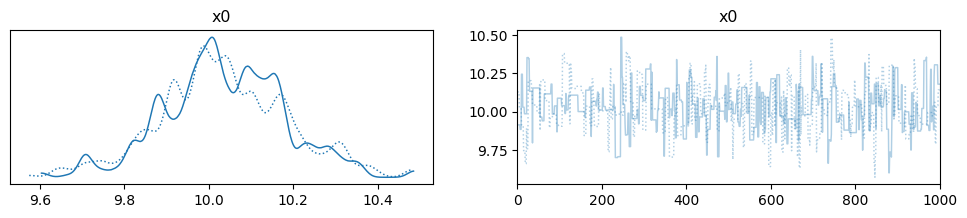

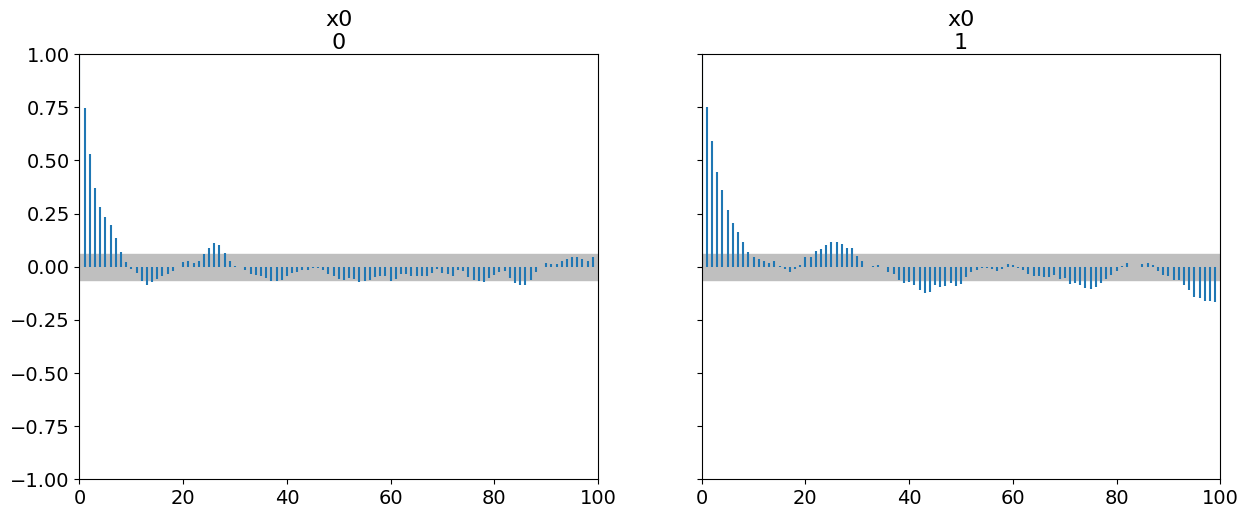

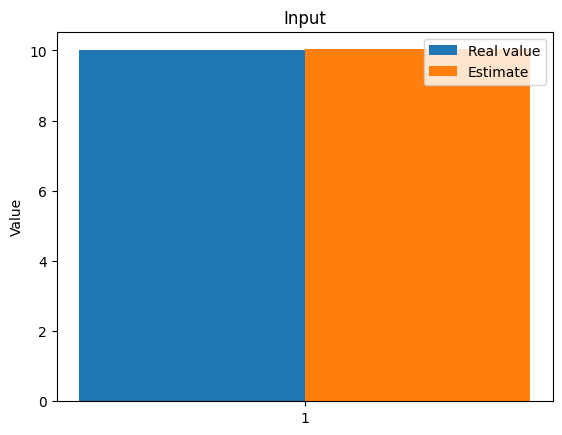

The function param_inverse took 608.684716463089 seconds.
Sampling chain 1/2


Running chain, α = 0.32: 100%|██████████| 3000/3000 [04:58<00:00, 10.04it/s]


Sampling chain 2/2


Running chain, α = 0.33: 100%|██████████| 3000/3000 [04:58<00:00, 10.05it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [10.027]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  10.027  0.15   9.749   10.285      0.007    0.005     430.0     316.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.027]



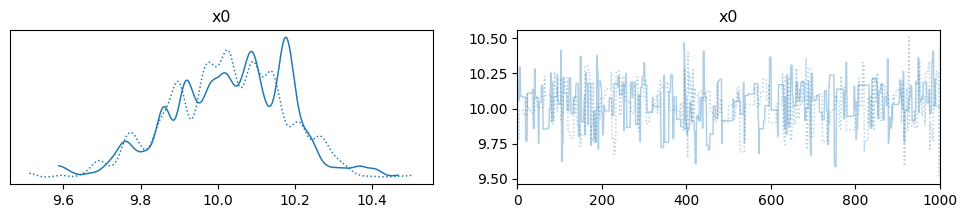

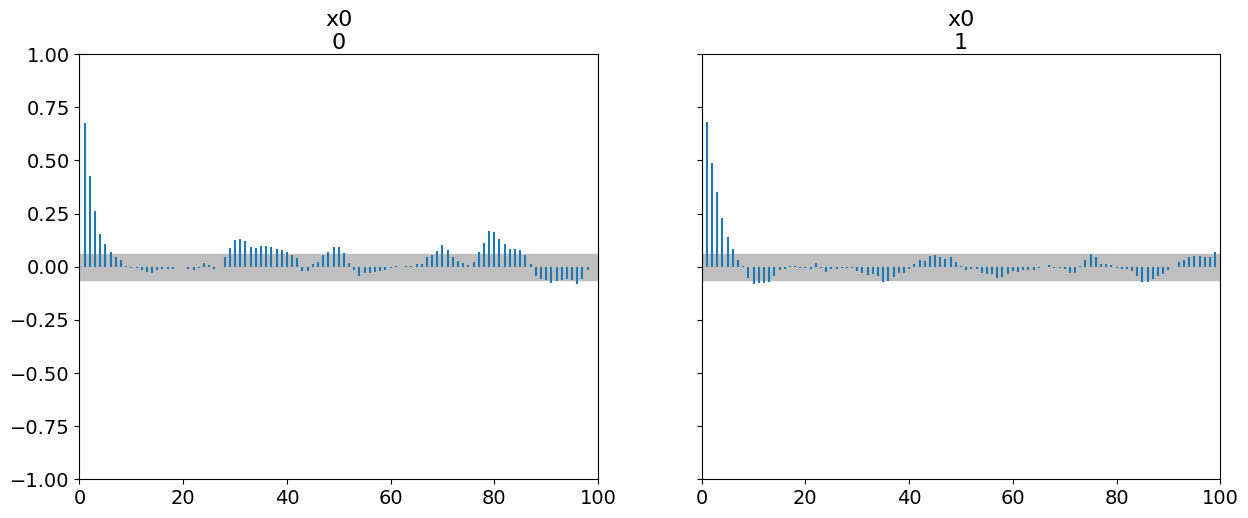

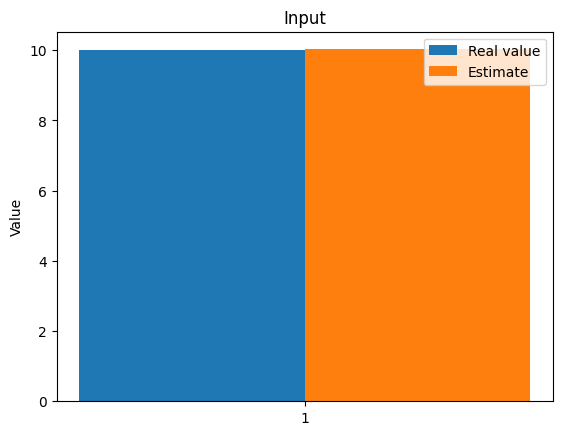

The function param_inverse took 609.055047750473 seconds.
The best estimate is given by: sigma_noise=0.05, number of data=50, sigma=2.0, rwmh_scaling=1.0
(50,)
real values are [10]
Sampling chain 1/2


Running chain, α = 0.23:  73%|███████▎  | 2203/3000 [02:07<00:45, 17.34it/s]


KeyboardInterrupt: 

In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([deltas[1]])
sigma = np.array([ 0.5,2.])
rwmh_scaling = np.array([2., 1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)

estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)





Sampling chain 1/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:51<00:00, 10.29it/s]


Sampling chain 2/2


Running chain, α = 0.11:   1%|          | 37/3000 [00:03<05:21,  9.22it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.25: 100%|██████████| 3000/3000 [05:05<00:00,  9.81it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [11.998]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.998  3.91    8.08   15.945      2.754    2.329       3.0      92.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [11.998]



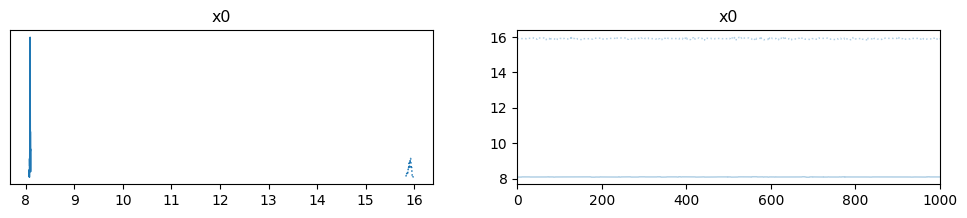

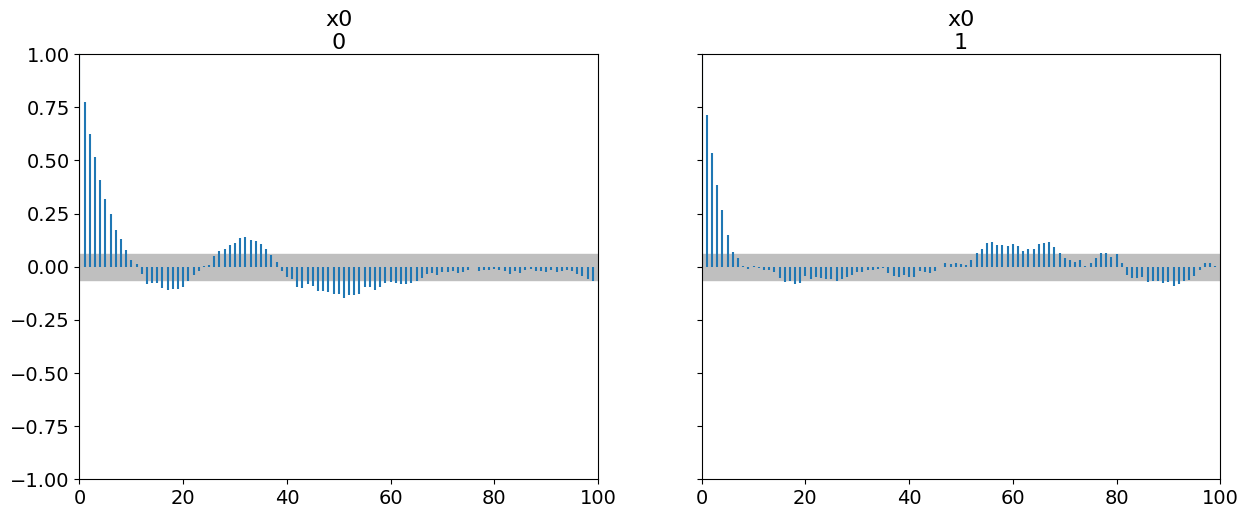

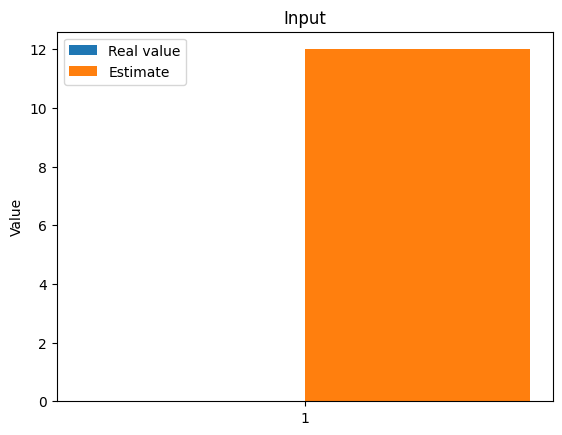

The function param_inverse took 606.0021507740021 seconds.
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [05:08<00:00,  9.71it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [05:07<00:00,  9.75it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.089]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.089  0.005   8.079    8.099        0.0      0.0     243.0     330.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [8.089]



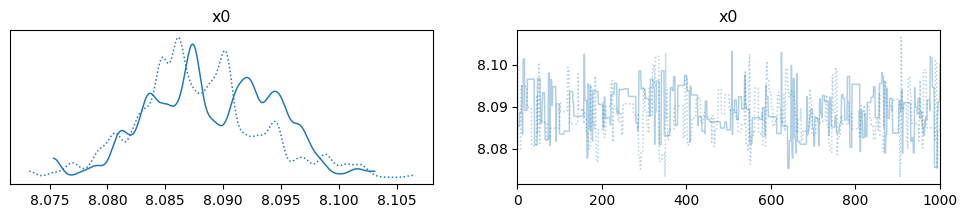

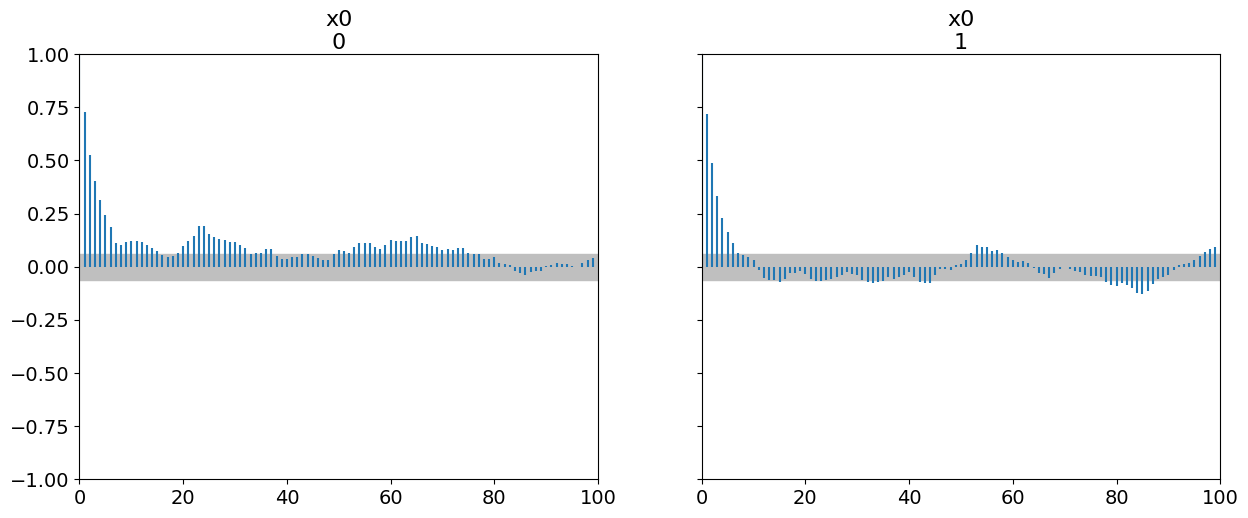

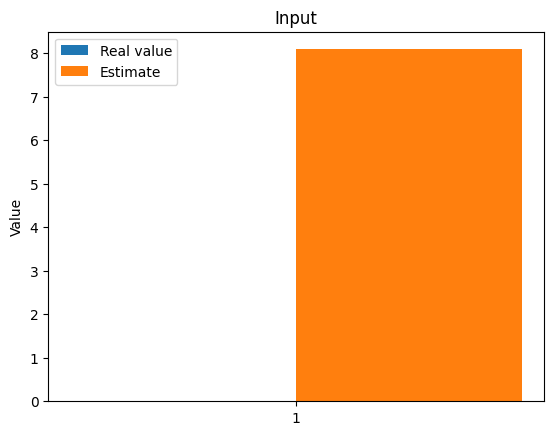

The function param_inverse took 627.1961989402771 seconds.
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [05:08<00:00,  9.73it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [05:08<00:00,  9.74it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.062]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.062  0.068   7.896    8.134      0.004    0.003     273.0     393.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [8.062]



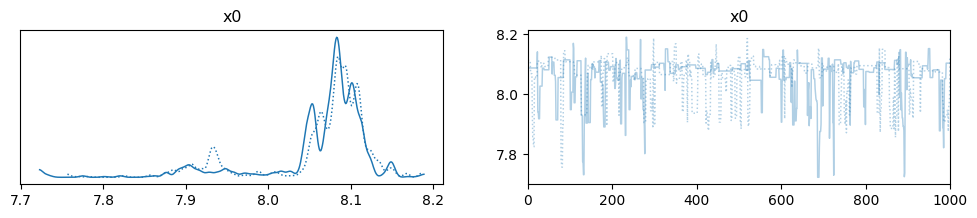

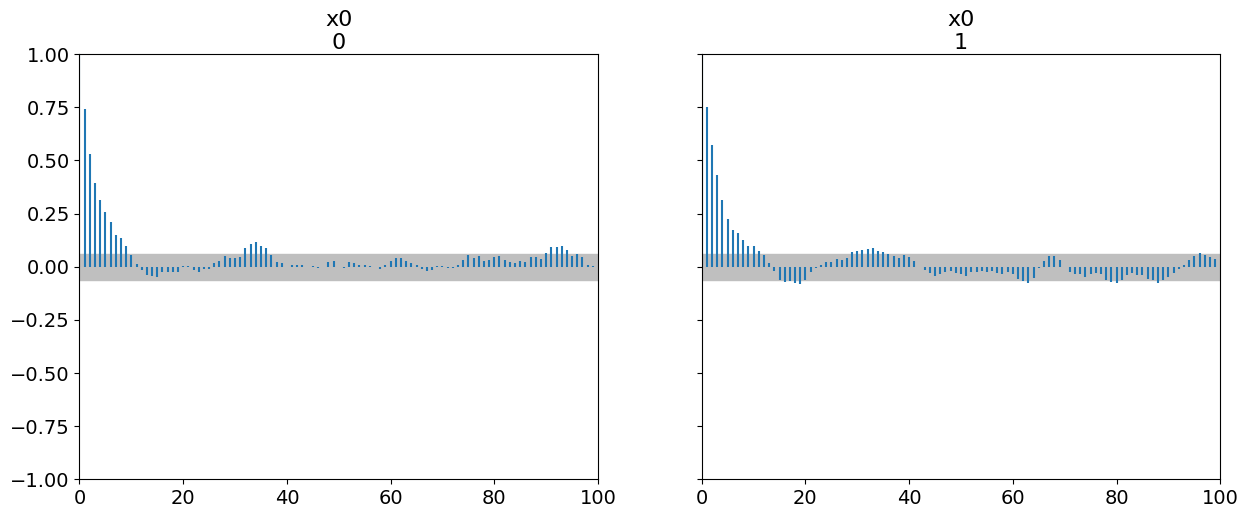

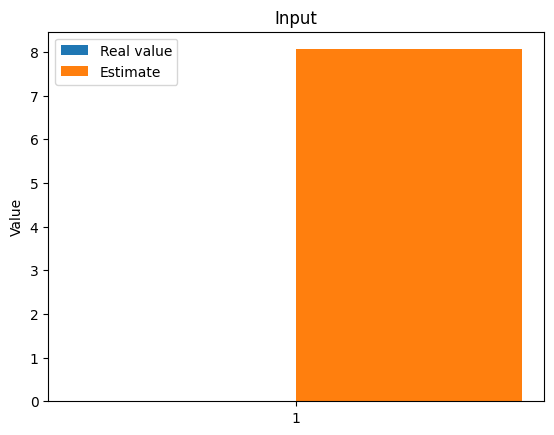

The function param_inverse took 617.3224132061005 seconds.
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [05:08<00:00,  9.71it/s]


Sampling chain 2/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [05:08<00:00,  9.72it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.067]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.067  0.065    7.91    8.146      0.005    0.003     225.0     326.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.067]



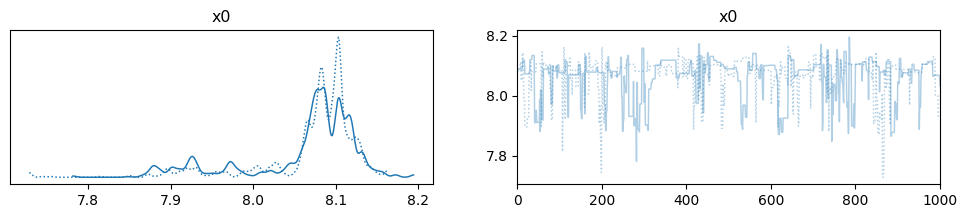

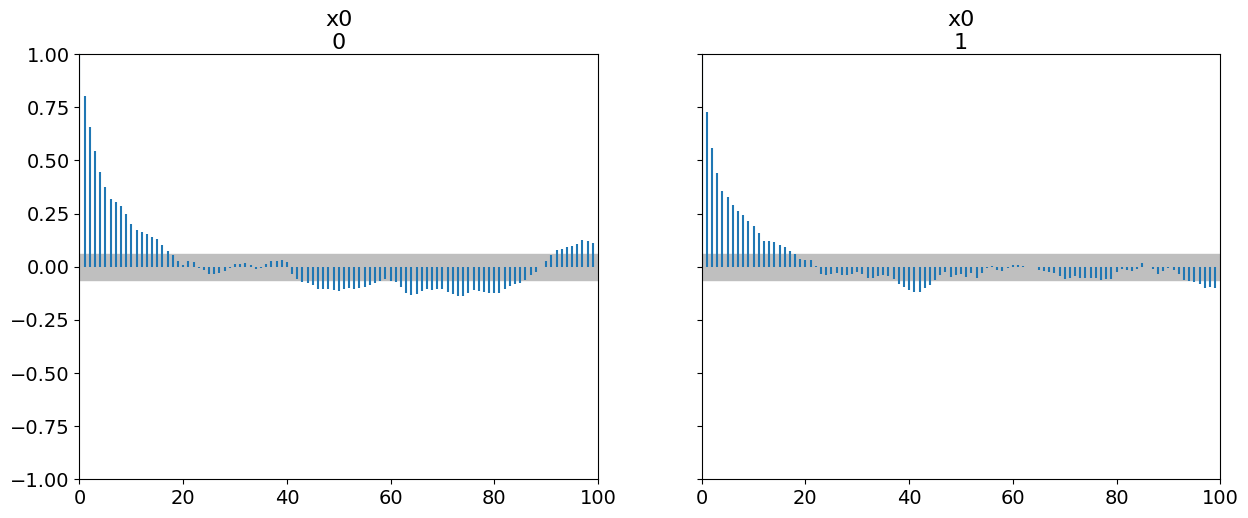

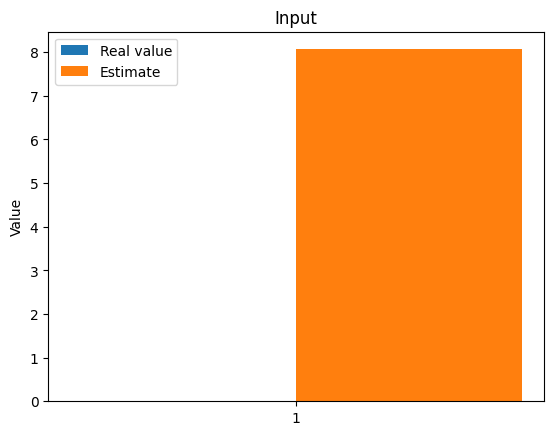

The function param_inverse took 619.0248923301697 seconds.
Sampling chain 1/2


Running chain, α = 0.08:   2%|▏         | 48/3000 [00:04<04:56,  9.95it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:56<00:00, 10.13it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:54<00:00, 10.19it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [15.907]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  15.907  0.037  15.837   15.976      0.002    0.002     289.0     252.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [15.907]



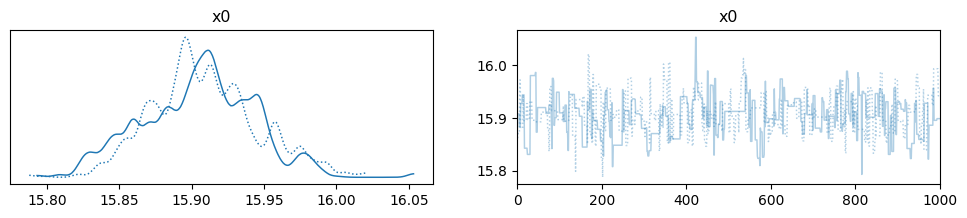

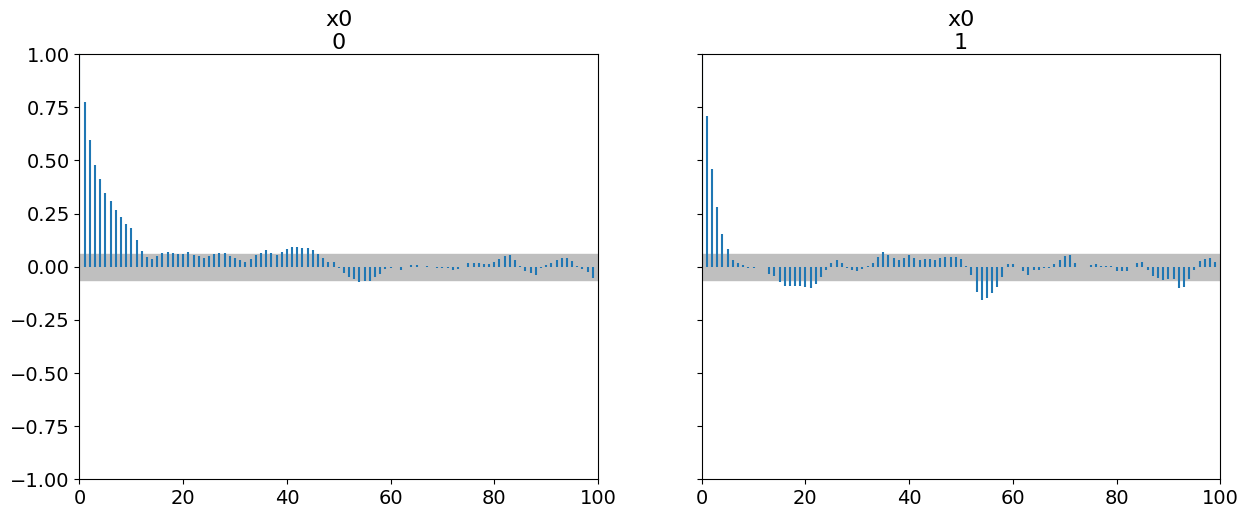

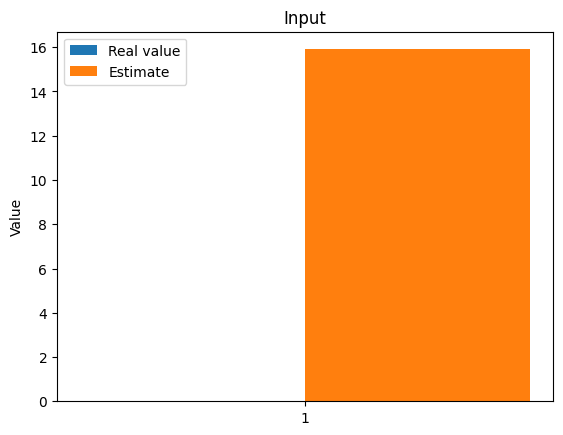

The function param_inverse took 601.7210626602173 seconds.
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:54<00:00, 10.19it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:54<00:00, 10.19it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.081]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.081  0.008   8.067    8.095        0.0      0.0     349.0     318.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.081]



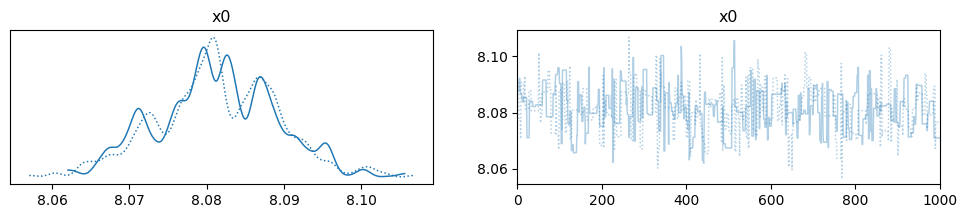

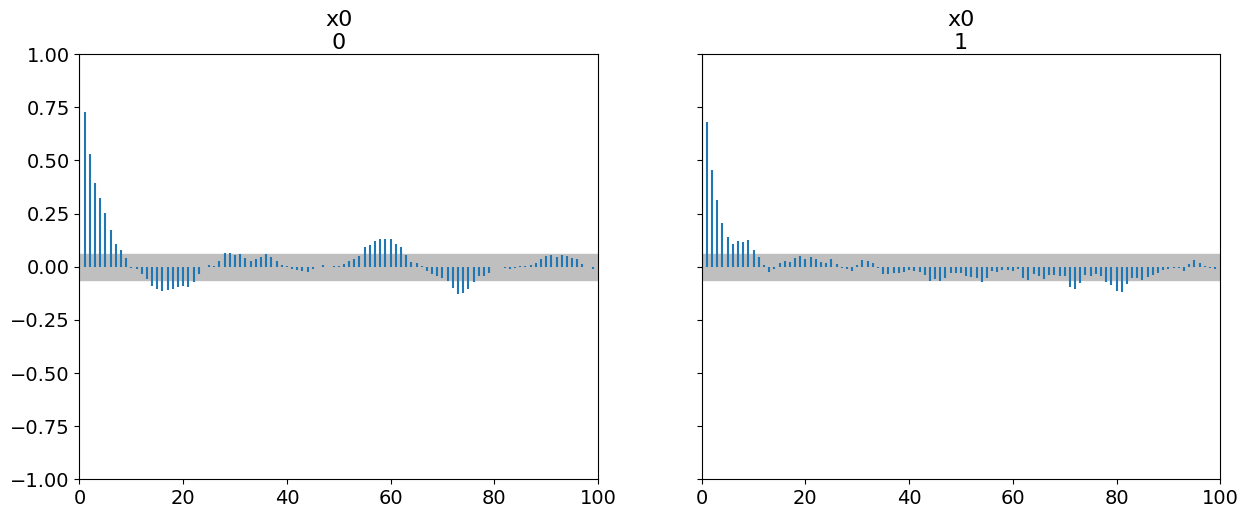

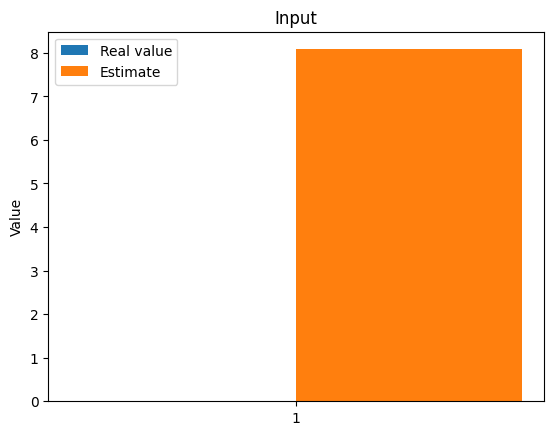

The function param_inverse took 590.1554718017578 seconds.
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:57<00:00, 10.10it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:54<00:00, 10.19it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [11.909]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.909  3.829   7.982    15.95      2.695     2.28       3.0     221.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [11.909]



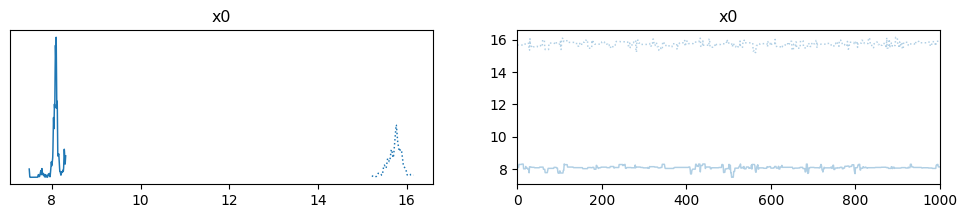

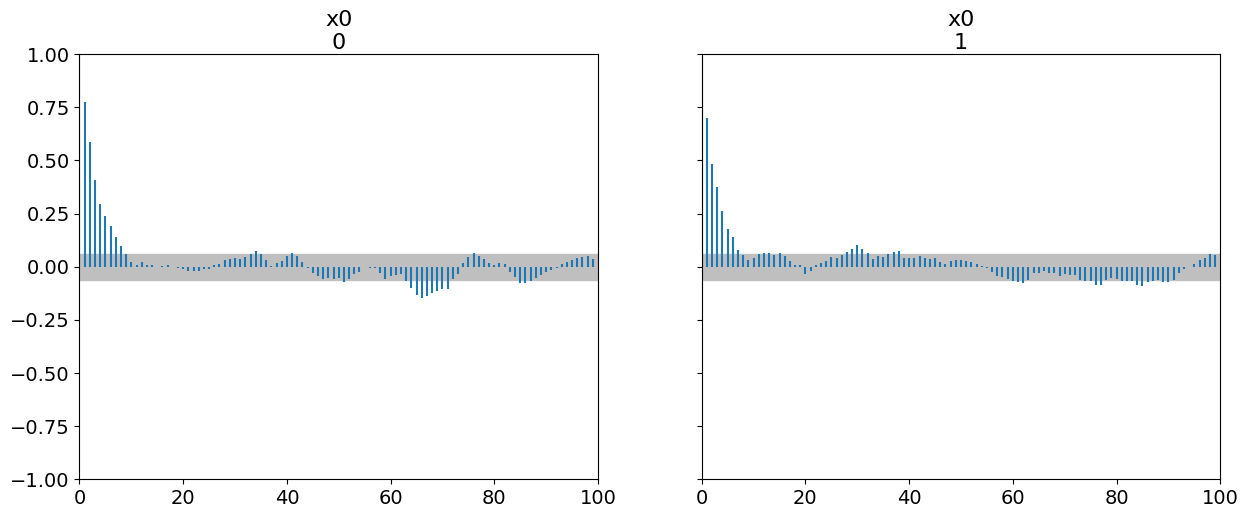

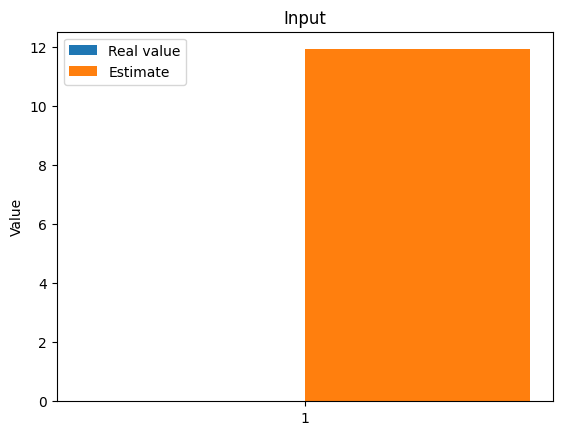

The function param_inverse took 592.7913415431976 seconds.
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:54<00:00, 10.18it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [04:55<00:00, 10.17it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.058]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.058  0.132   7.762    8.288      0.008    0.005     291.0     298.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.058]



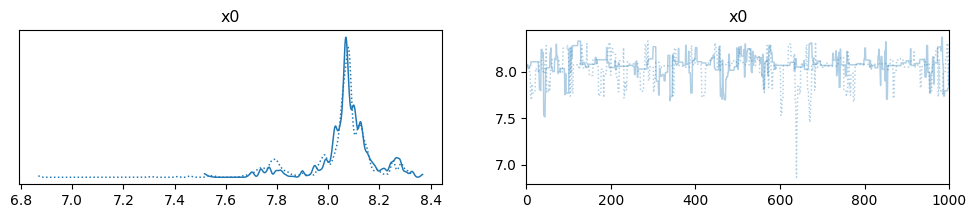

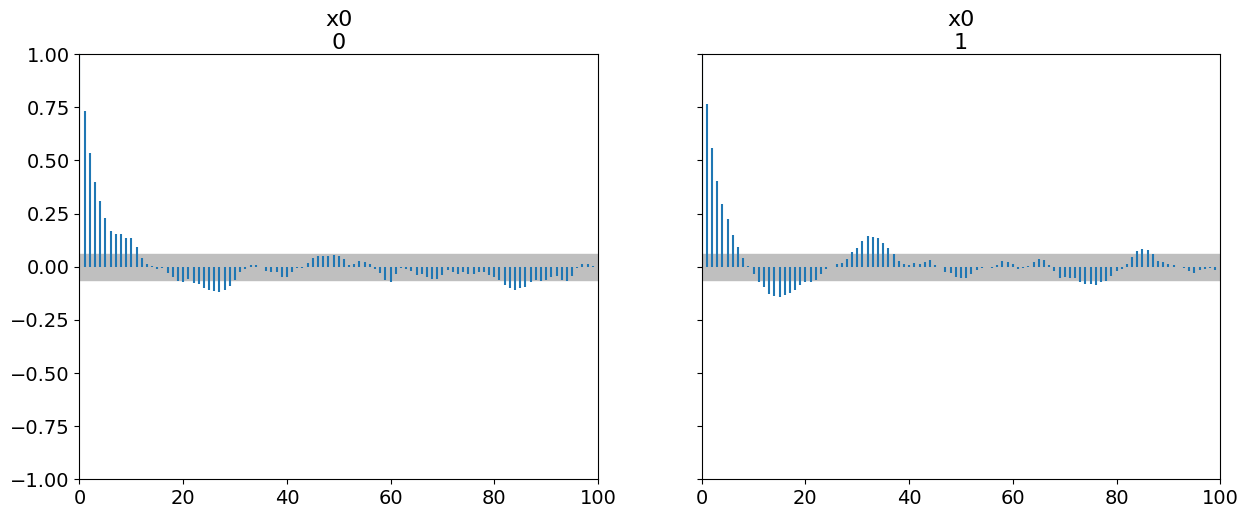

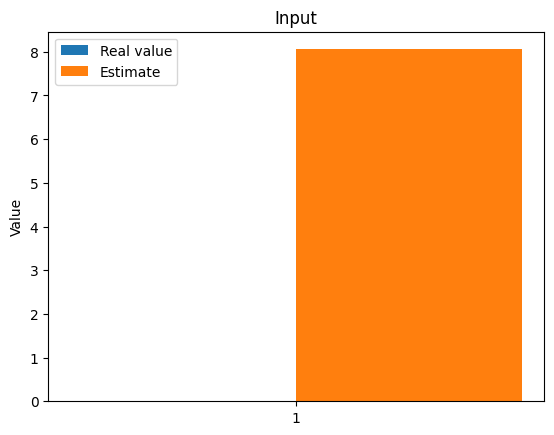

The function param_inverse took 602.5584478378296 seconds.
Sampling chain 1/2


Running chain, α = 0.11:   1%|          | 17/3000 [00:01<05:02,  9.85it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.26: 100%|██████████| 3000/3000 [05:08<00:00,  9.72it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [05:08<00:00,  9.72it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [11.999]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.999  3.911   8.077   15.945      2.754     2.33       3.0     134.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [11.999]



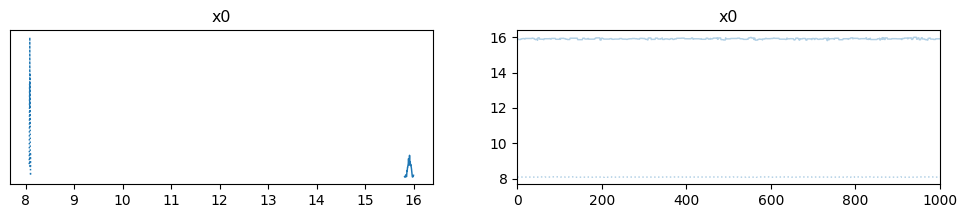

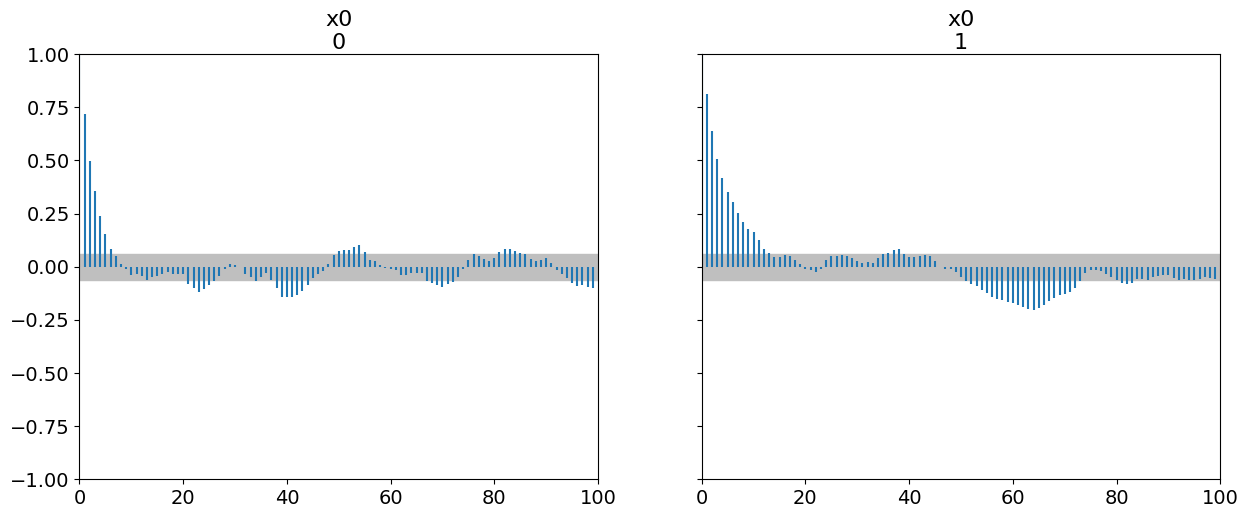

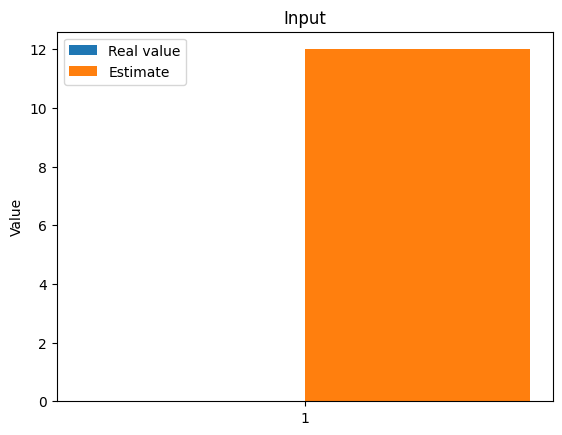

The function param_inverse took 634.8953642845154 seconds.
Sampling chain 1/2


Running chain, α = 0.22: 100%|██████████| 3000/3000 [05:09<00:00,  9.68it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 3000/3000 [05:08<00:00,  9.71it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.089]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.089  0.005    8.08    8.098        0.0      0.0     343.0     264.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.089]



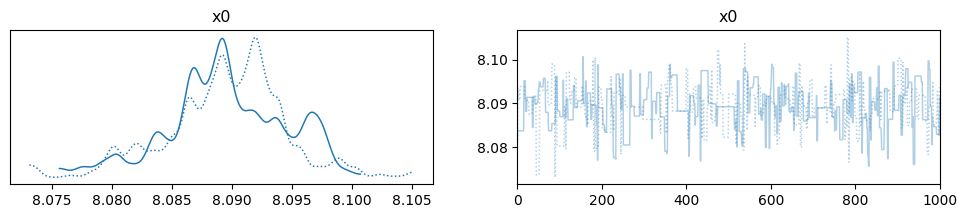

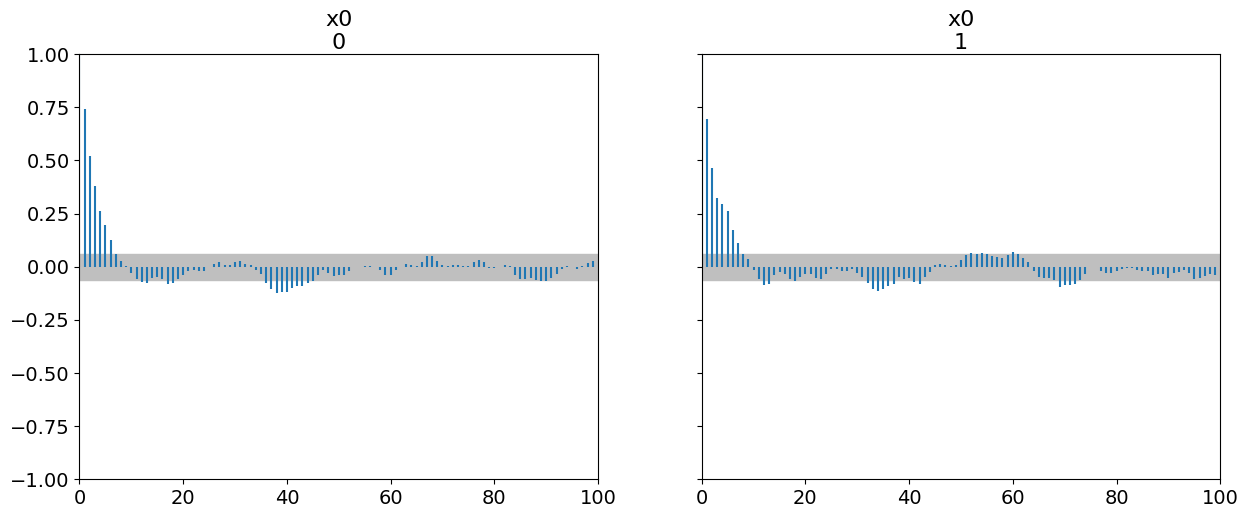

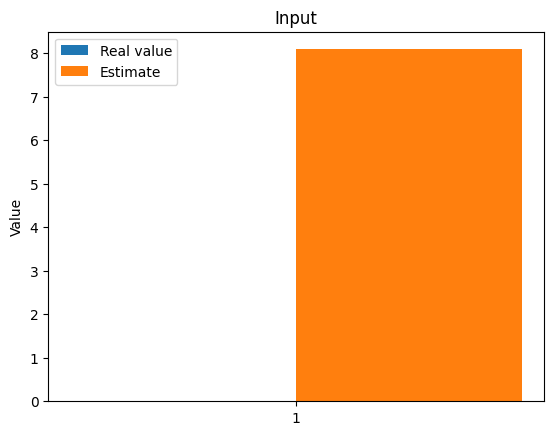

The function param_inverse took 619.8886849880219 seconds.
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [05:11<00:00,  9.64it/s]


Sampling chain 2/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [05:12<00:00,  9.60it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [7.923]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.923  7.867  -0.066   15.924       5.54    4.687       3.0     178.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [7.923]



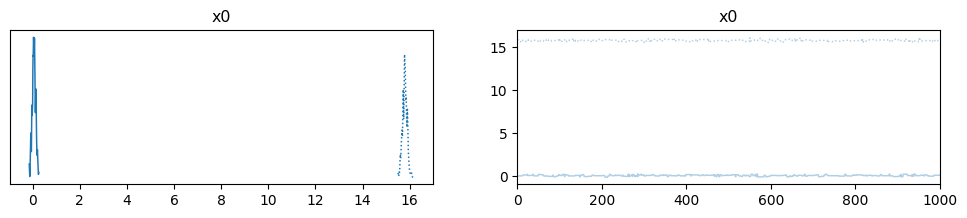

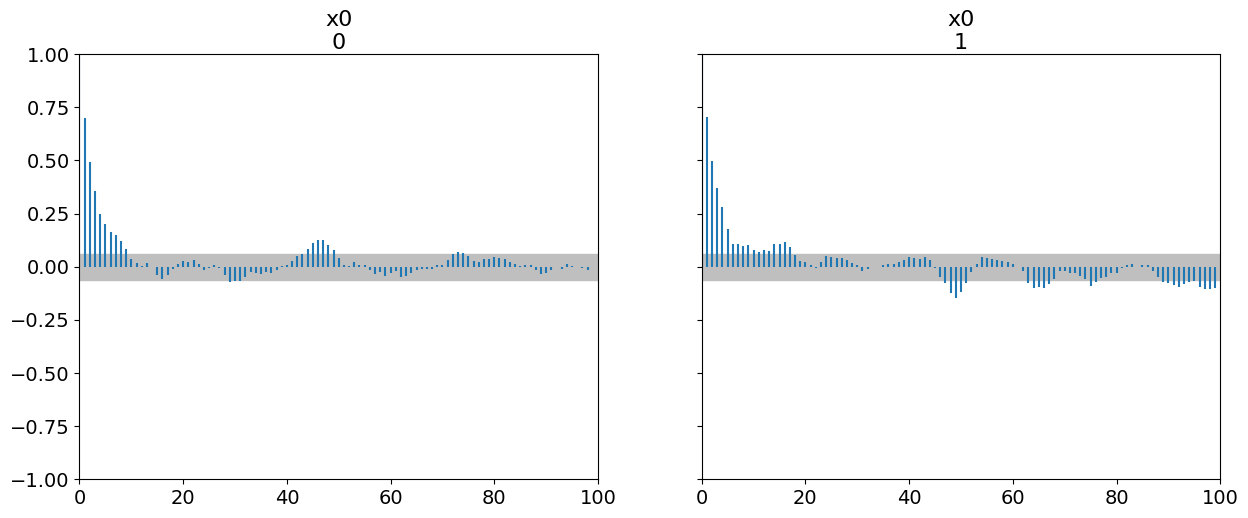

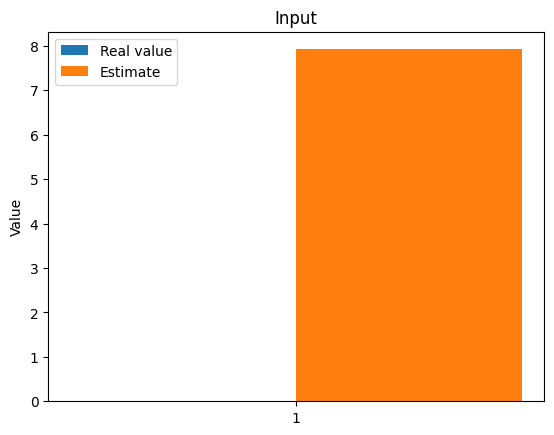

The function param_inverse took 624.8424263000488 seconds.
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:09<00:00,  9.68it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [05:09<00:00,  9.69it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.066]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.066  0.064   7.909    8.144      0.005    0.004     156.0     303.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.066]



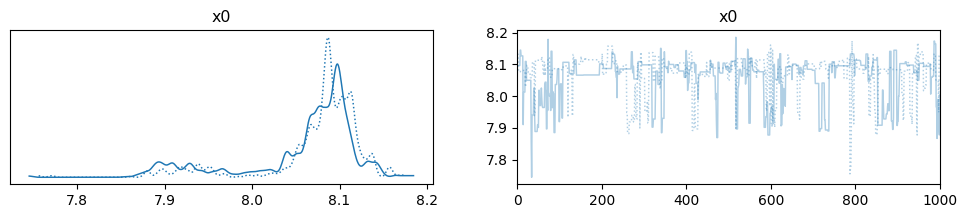

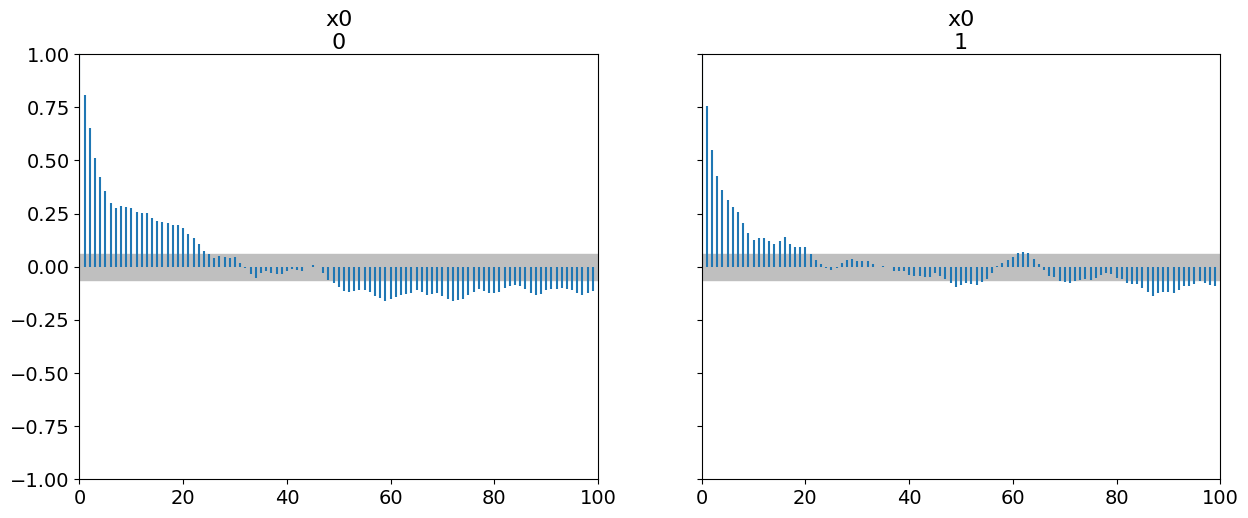

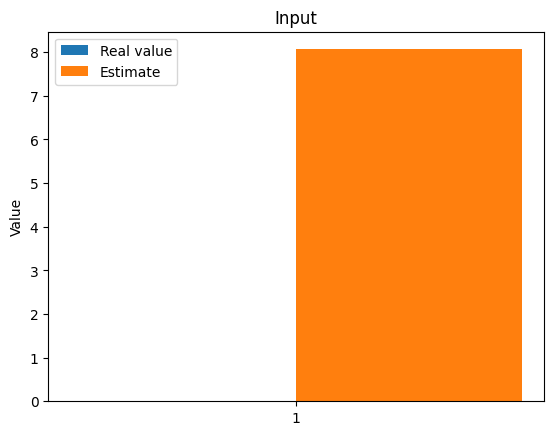

The function param_inverse took 620.6439642906189 seconds.
Sampling chain 1/2


Running chain, α = 0.08:   2%|▏         | 50/3000 [00:04<04:41, 10.47it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:55<00:00, 10.16it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:55<00:00, 10.15it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [11.989]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.989  3.909   8.065   15.938      2.753    2.329       3.0     126.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [11.989]



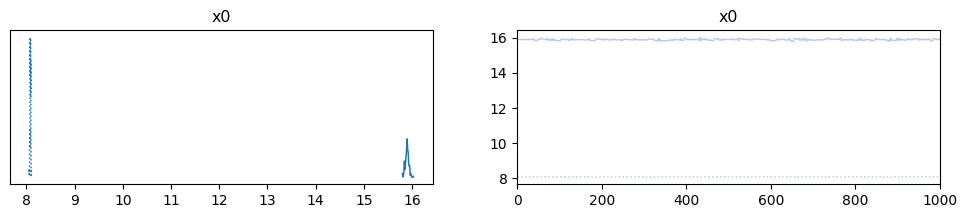

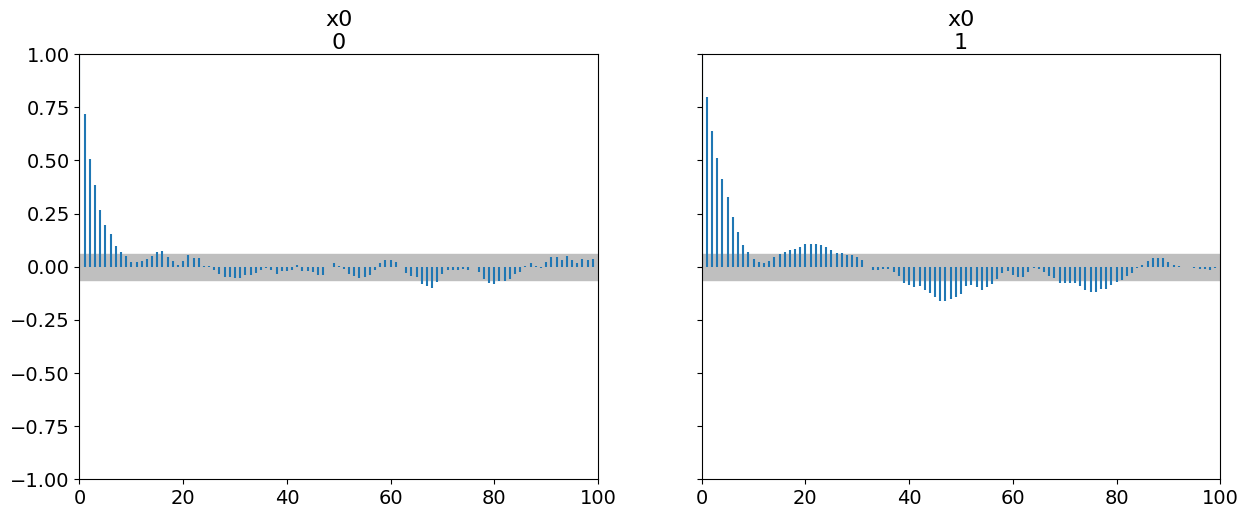

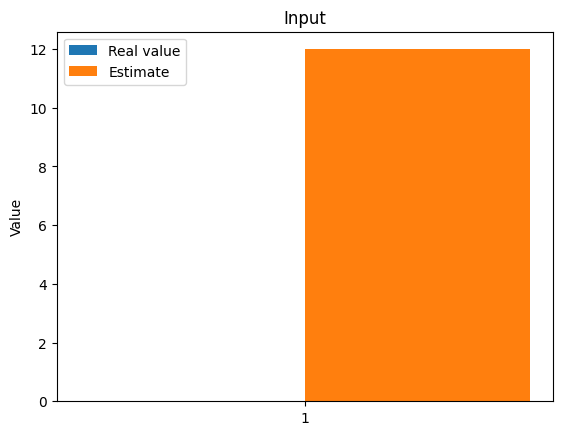

The function param_inverse took 608.628408908844 seconds.
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [04:55<00:00, 10.17it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:56<00:00, 10.12it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.08]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.08  0.007   8.065    8.093        0.0      0.0     326.0     297.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.08]



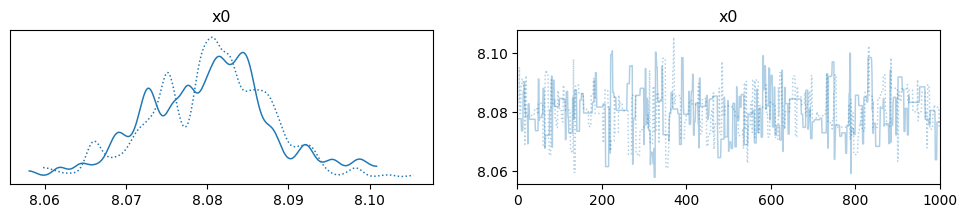

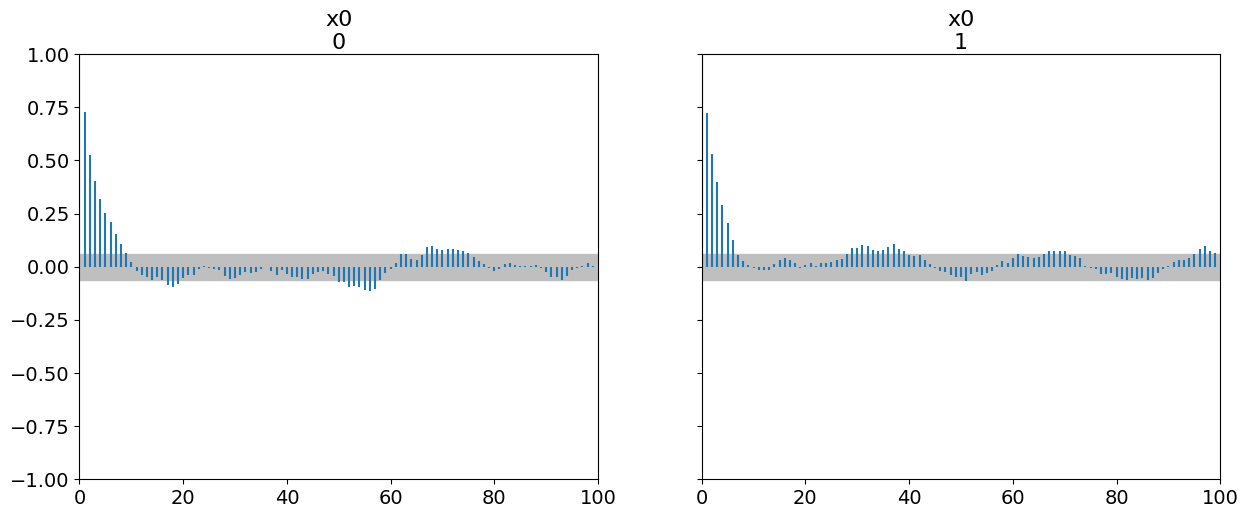

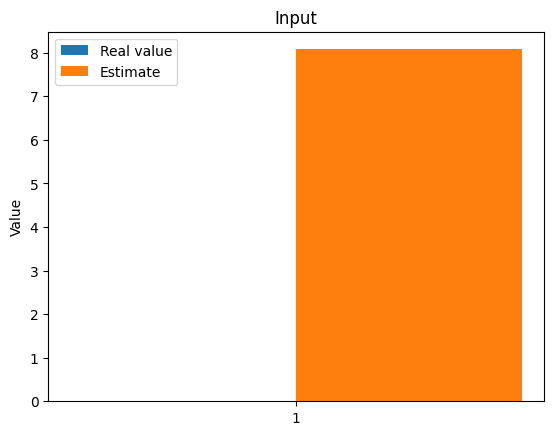

The function param_inverse took 604.2838728427887 seconds.
Sampling chain 1/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [04:57<00:00, 10.09it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:55<00:00, 10.14it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [15.703]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  15.703  0.149  15.407   15.974      0.008    0.006     322.0     246.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [15.703]



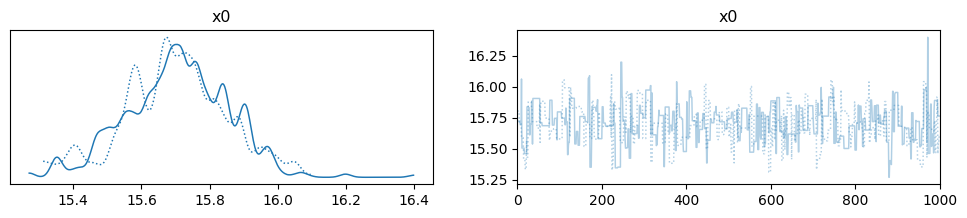

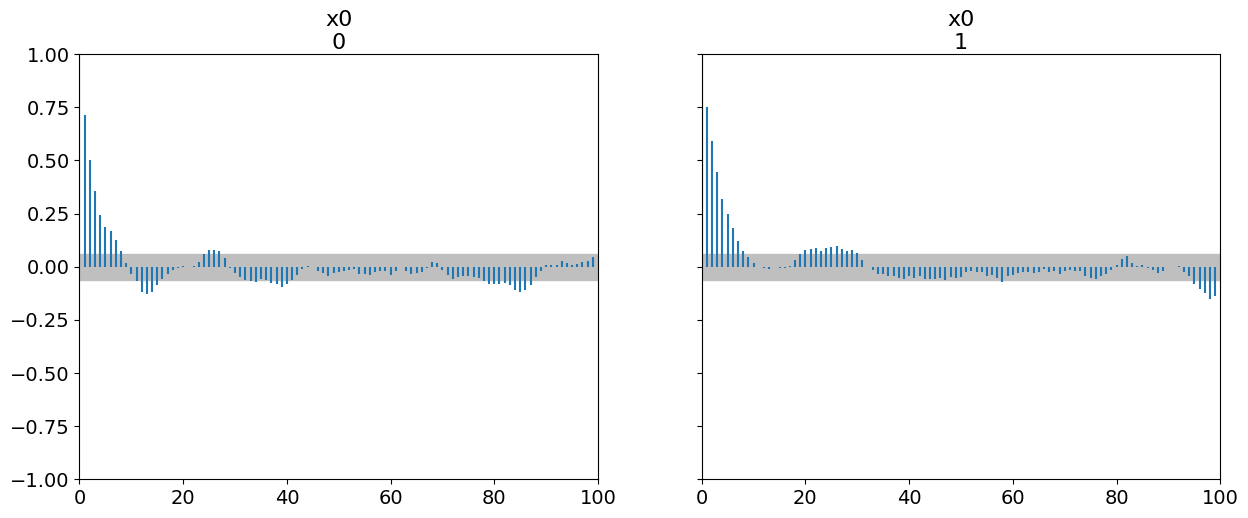

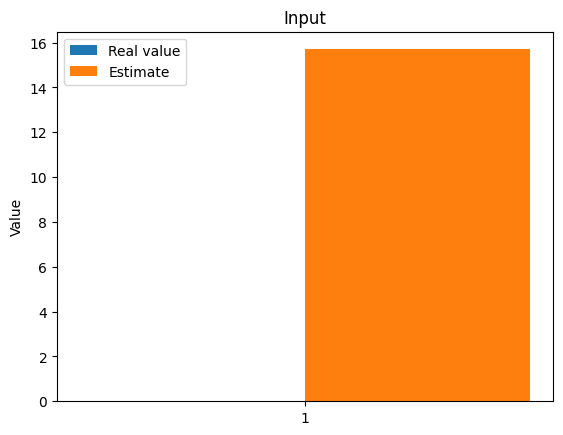

The function param_inverse took 594.3893549442291 seconds.
Sampling chain 1/2


Running chain, α = 0.33: 100%|██████████| 3000/3000 [04:56<00:00, 10.12it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:57<00:00, 10.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [8.061]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.061  0.12   7.752    8.258      0.008    0.006     256.0     283.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [8.061]



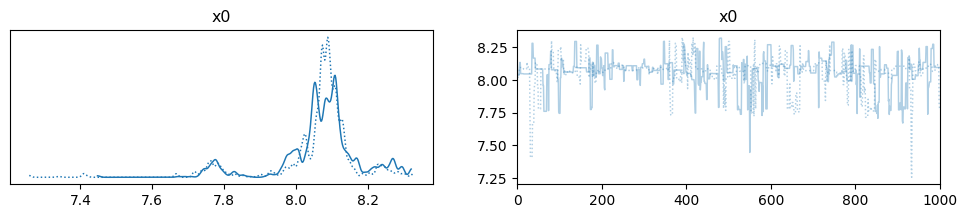

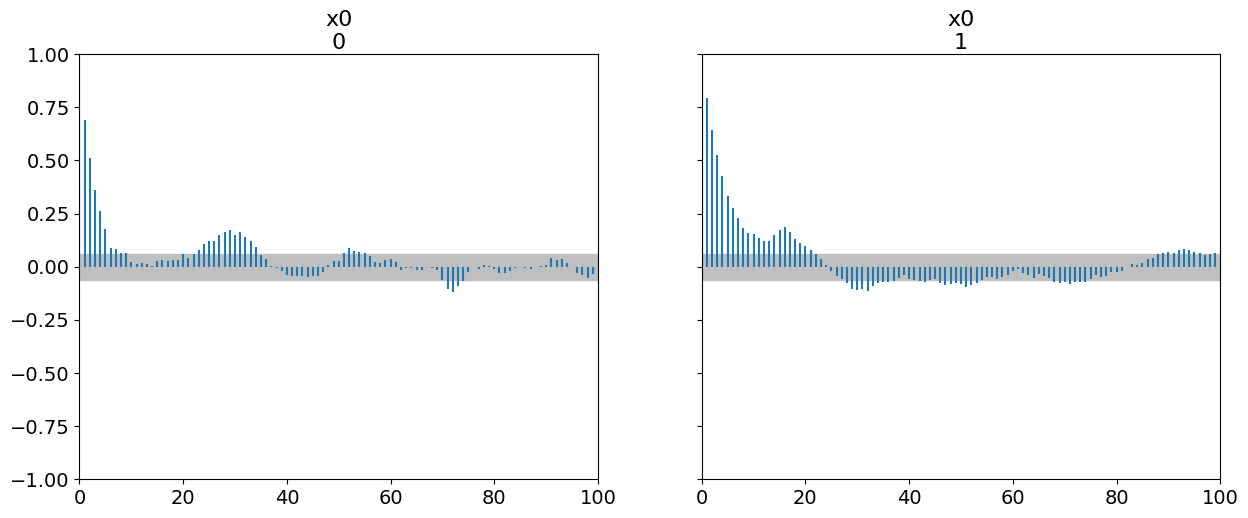

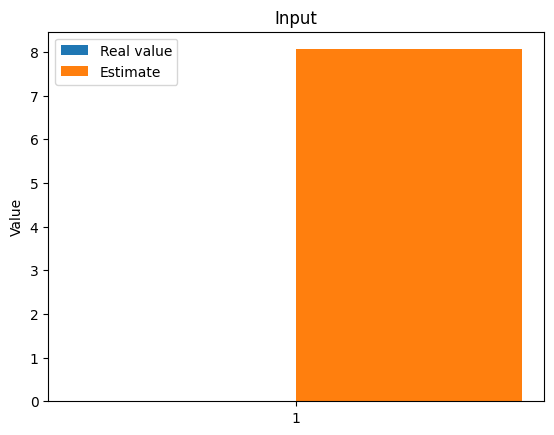

The function param_inverse took 610.1433551311493 seconds.
The best estimate is given by: sigma_noise=0.1, number of data=50, sigma=2.0, rwmh_scaling=2.0


In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([deltas[0]])
sigma = np.array([ 0.5,2.])
rwmh_scaling = np.array([2., 1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)

# estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
# estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)





Sample 3000 / 3000

Average acceptance rate: 0.262 MCMC scale: 0.11745459665093268 

Mean values = [0.00776017]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.235 MCMC scale: 0.12526750977085618 

Mean values = [0.00814853]
(2, 1, 1000)


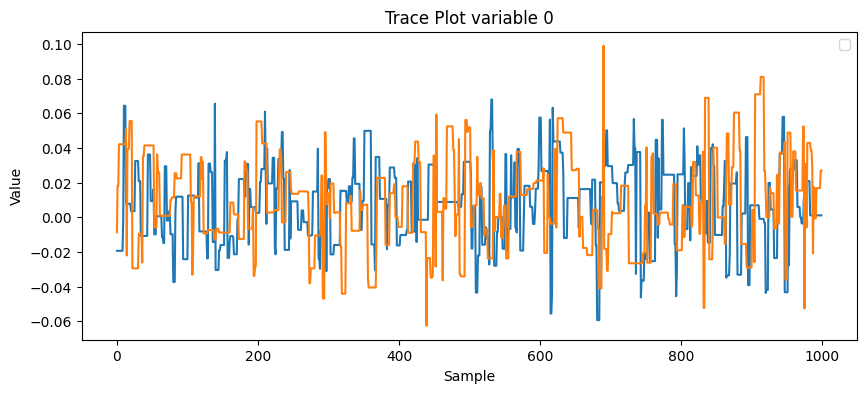

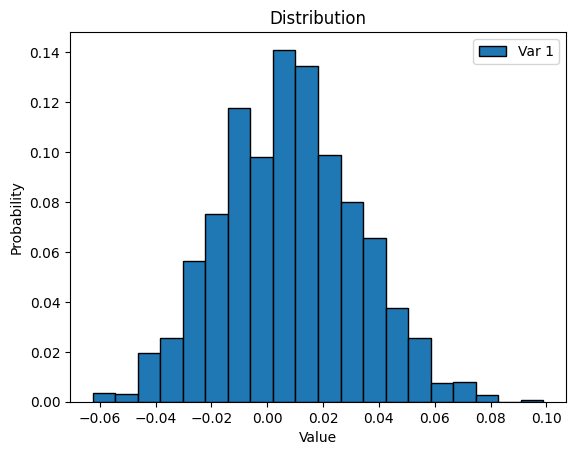

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 322.6379289917236


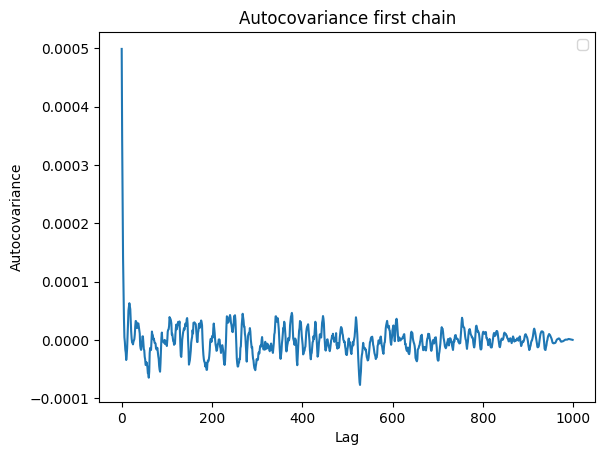

the difference between estimated values [0.00814853]



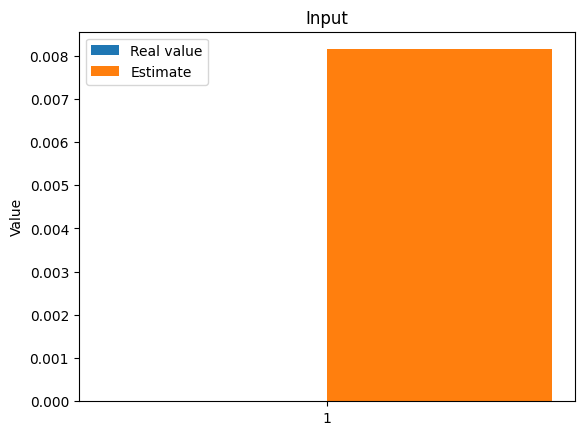

Sample 3000 / 3000

Average acceptance rate: 0.256 MCMC scale: 0.2515688300394112 

Mean values = [0.01813208]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.247 MCMC scale: 0.24029406147015603 

Mean values = [0.01869005]
(2, 1, 1000)


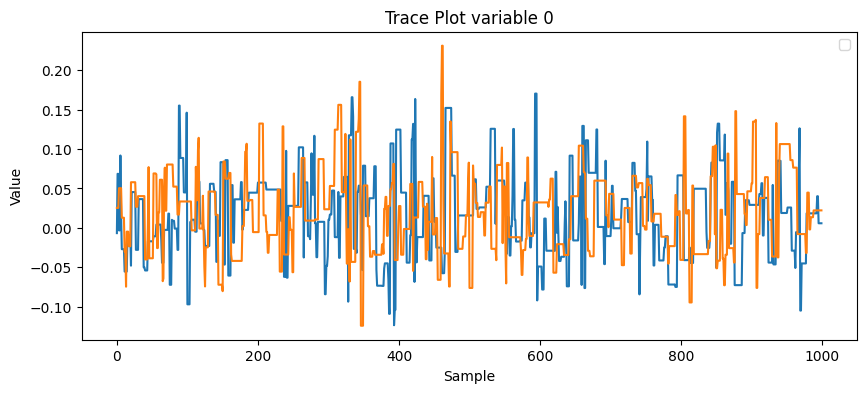

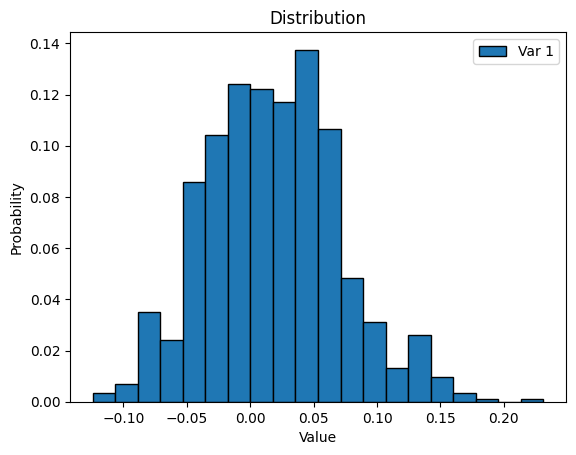

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 362.91033690436893


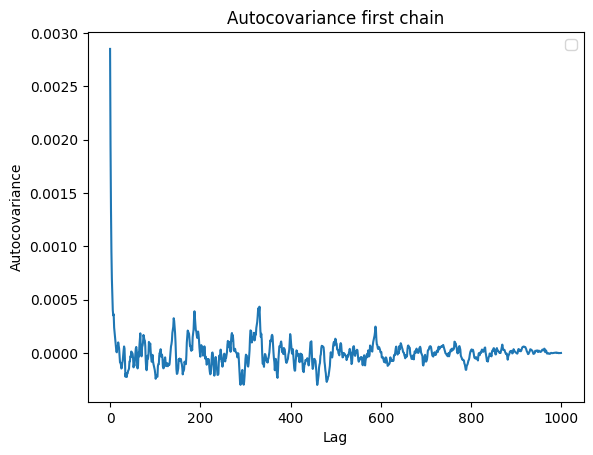

the difference between estimated values [0.01869005]



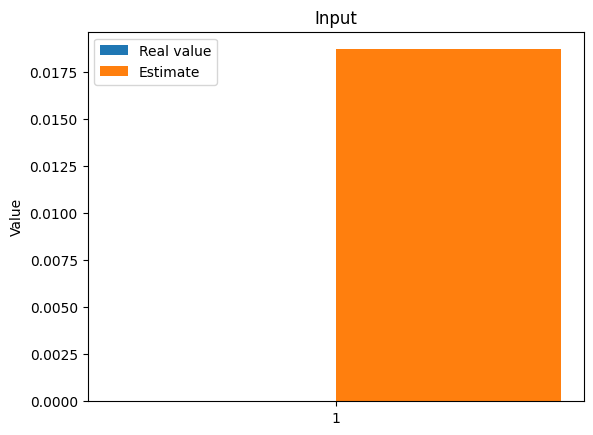

Sample 3000 / 3000

Average acceptance rate: 0.253 MCMC scale: 0.14460873825634396 

Mean values = [0.04498016]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.235 MCMC scale: 0.1408156973876696 

Mean values = [0.04268546]
(2, 1, 1000)


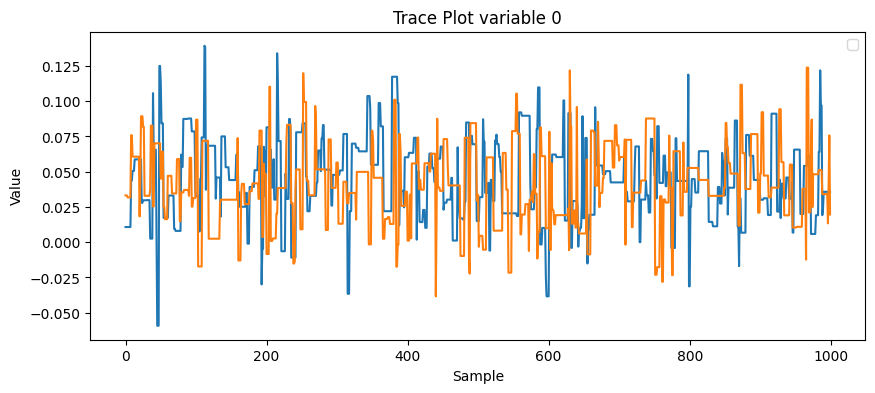

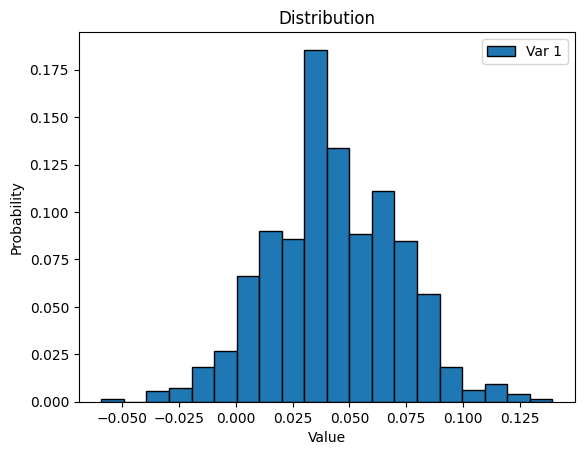

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 412.675535353956


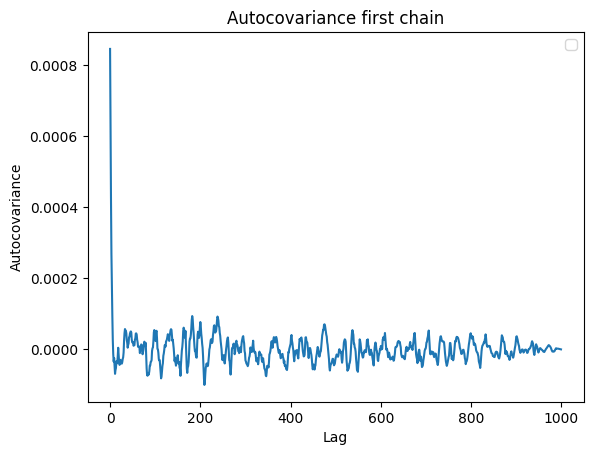

the difference between estimated values [0.04268546]



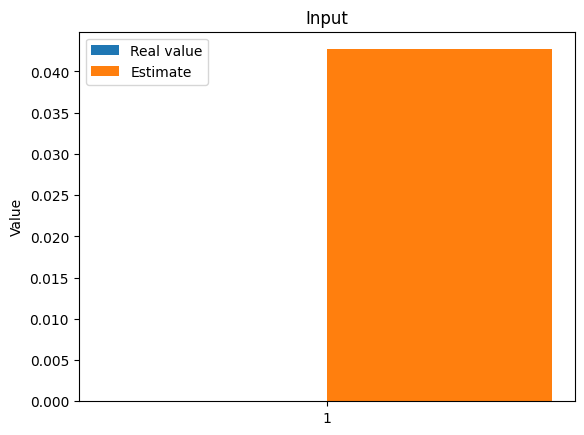

Sample 3000 / 3000

Average acceptance rate: 0.217 MCMC scale: 0.33371109207239785 

Mean values = [0.07323974]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.27 MCMC scale: 0.32685340180530603 

Mean values = [0.07079502]
(2, 1, 1000)


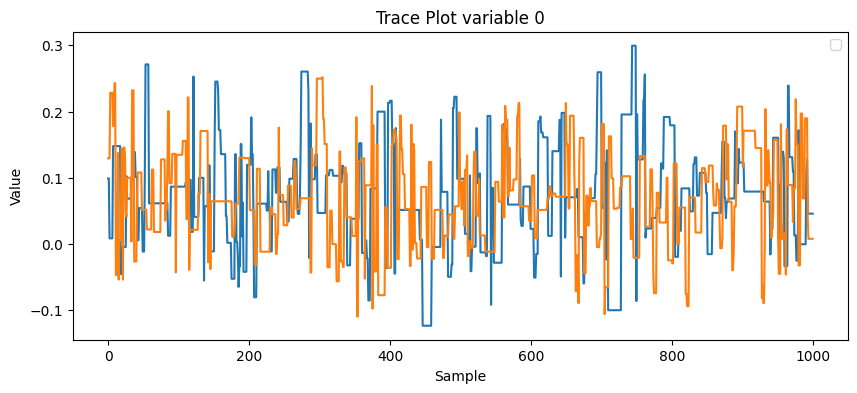

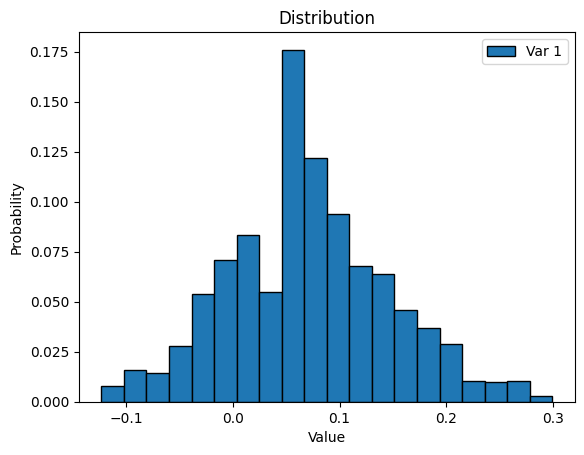

ESS values = 273.07172008130425


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


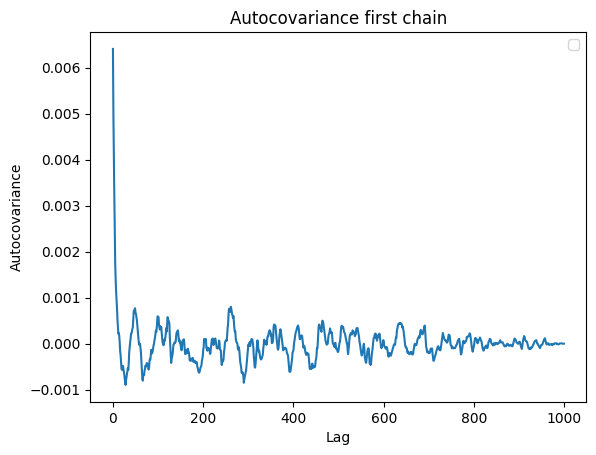

the difference between estimated values [0.07079502]



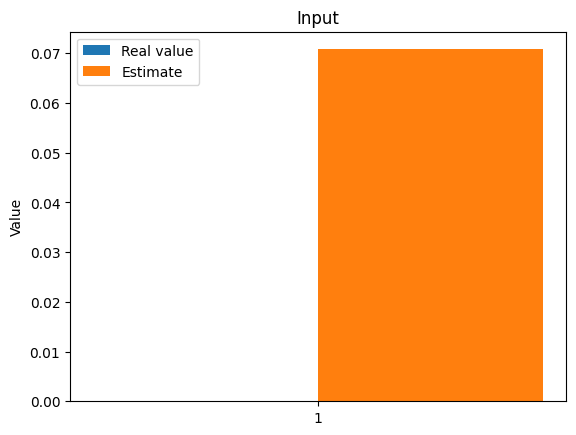

Sample 3000 / 3000

Average acceptance rate: 0.242 MCMC scale: 0.11969095972608727 

Mean values = [0.00466193]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.248 MCMC scale: 0.11666977343527697 

Mean values = [0.00496387]
(2, 1, 1000)


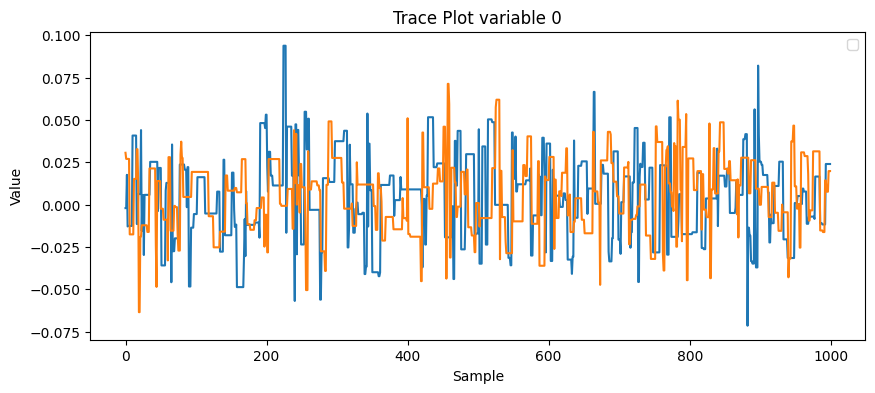

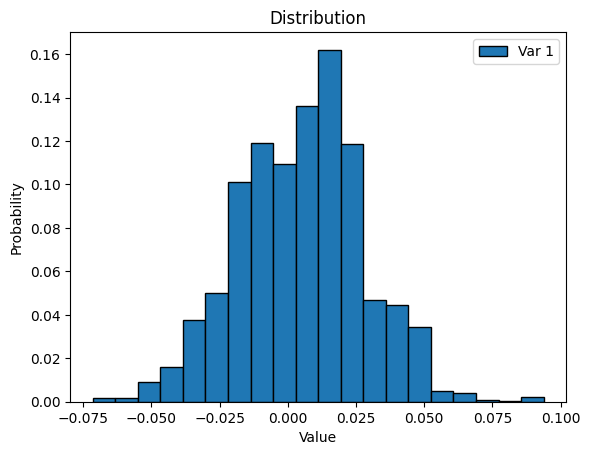

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 328.7975981696728


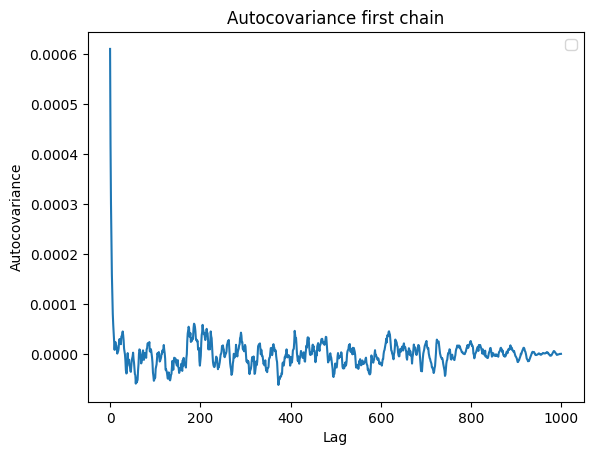

the difference between estimated values [0.00496387]



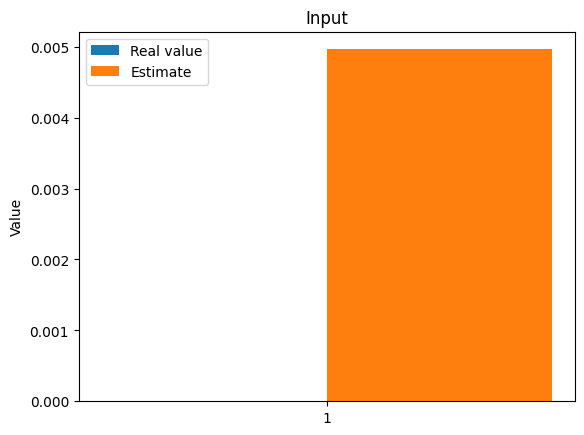

Sample 3000 / 3000

Average acceptance rate: 0.271 MCMC scale: 0.23630811811073307 

Mean values = [0.02613634]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.269 MCMC scale: 0.23144827201511622 

Mean values = [0.02469269]
(2, 1, 1000)


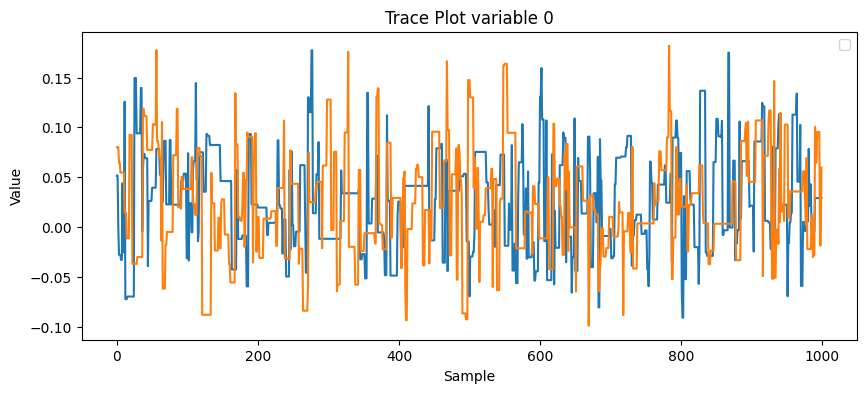

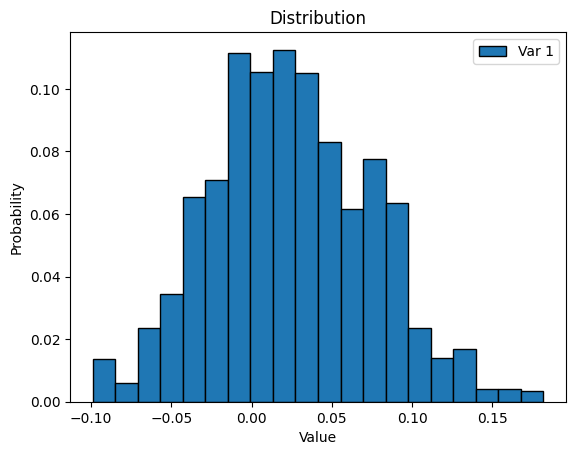

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 349.38913239322375


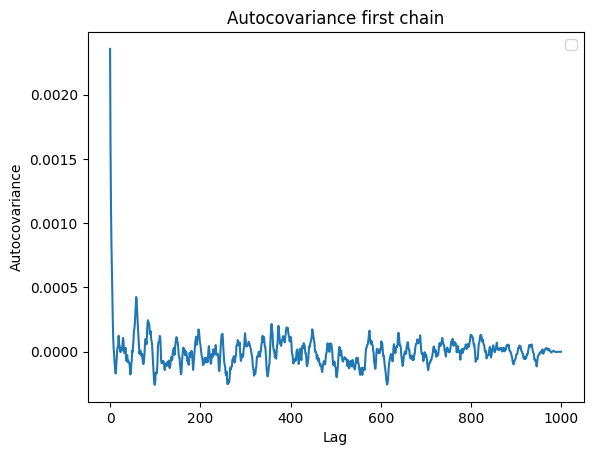

the difference between estimated values [0.02469269]



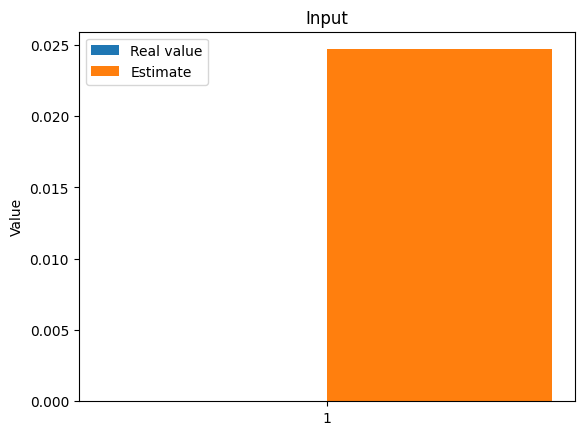

Sample 3000 / 3000

Average acceptance rate: 0.253 MCMC scale: 0.15818692548847743 

Mean values = [0.04412122]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.224 MCMC scale: 0.14864865219339465 

Mean values = [0.04303981]
(2, 1, 1000)


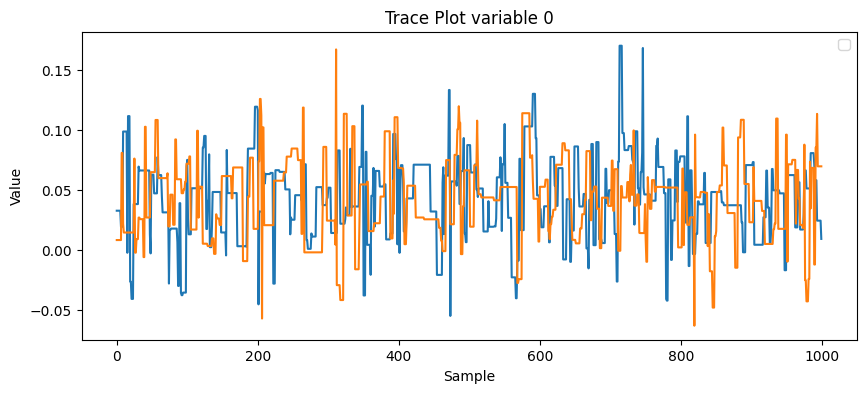

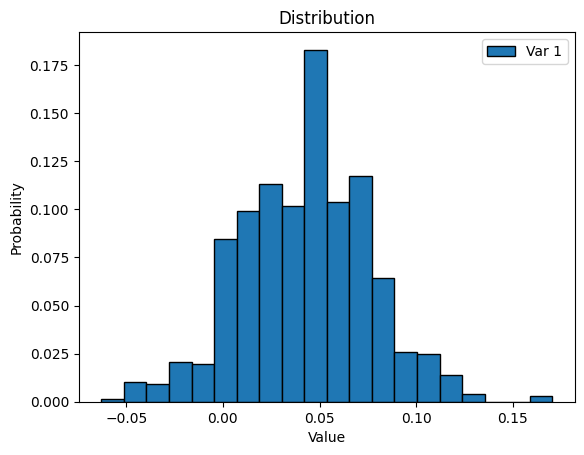

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 334.59997455158754


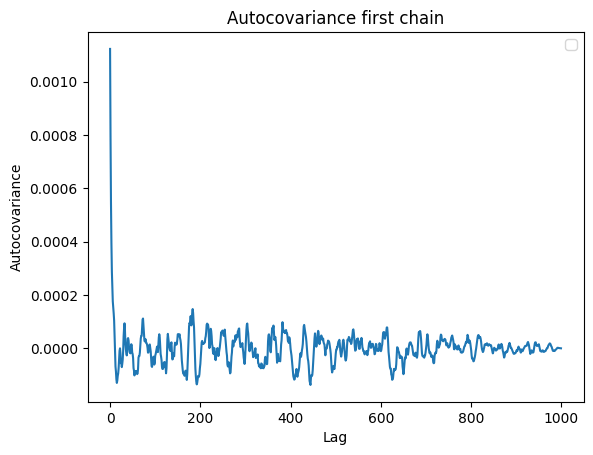

the difference between estimated values [0.04303981]



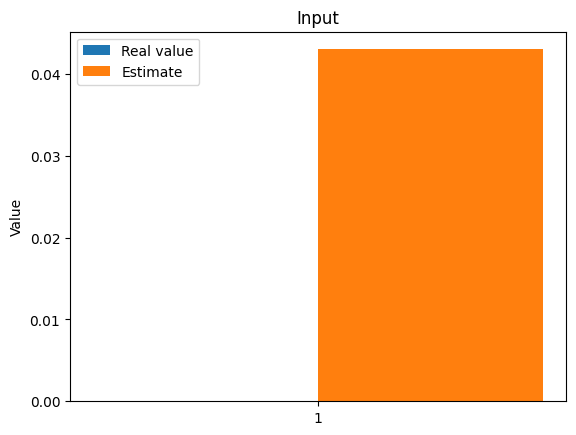

Sample 3000 / 3000

Average acceptance rate: 0.271 MCMC scale: 0.3439269796363466 

Mean values = [0.07124817]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.246 MCMC scale: 0.32881059759122666 

Mean values = [0.0704578]
(2, 1, 1000)


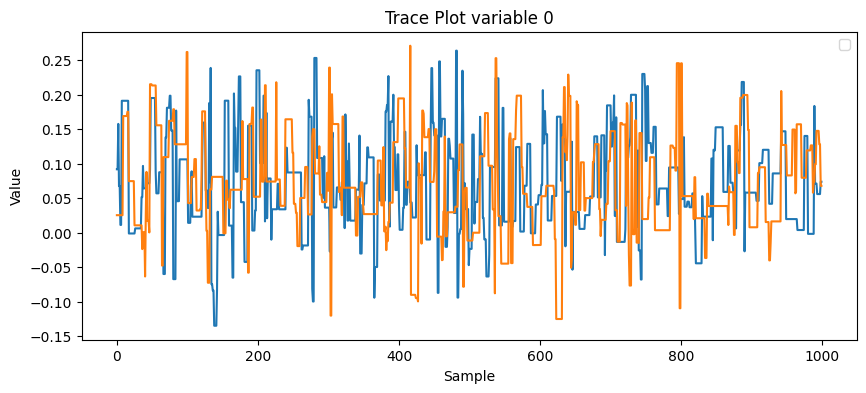

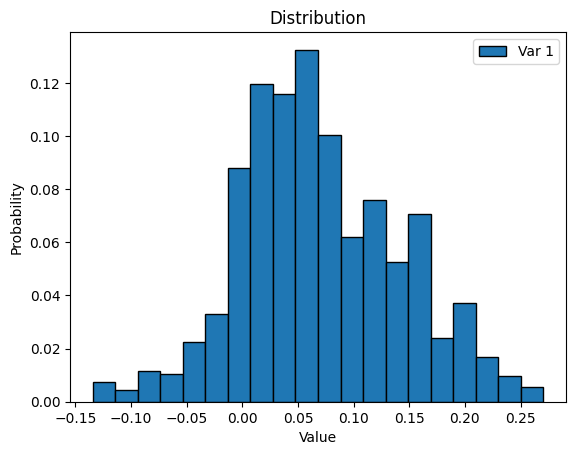

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 361.69286481162504


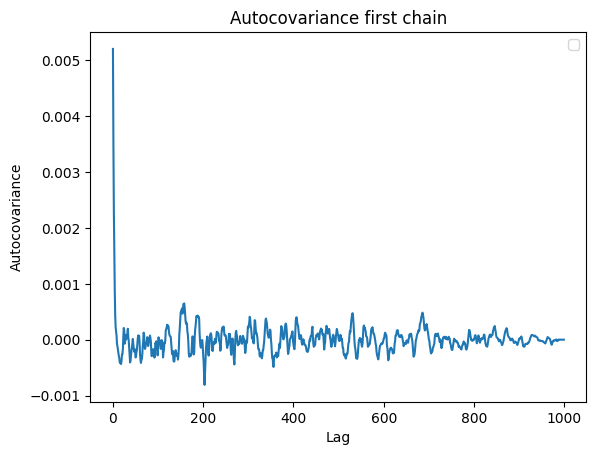

the difference between estimated values [0.0704578]



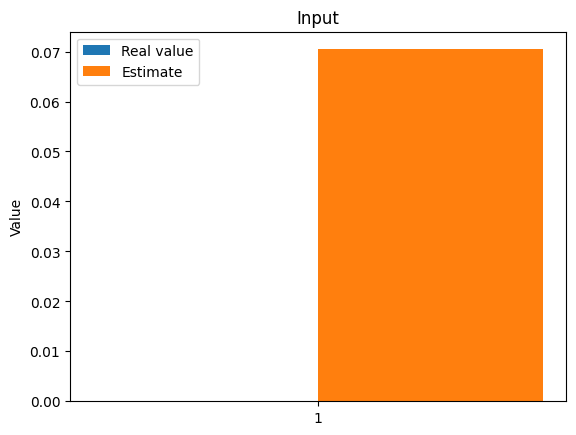

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([deltas[0]])
proposal_sd = [0.5,2.]
adapt = True
n_data = [50,30]

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 


Sample 3000 / 3000

Average acceptance rate: 0.15 MCMC scale: 0.029734296016821673 

Mean values = [1.28865013]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.162 MCMC scale: 0.028739222162631948 

Mean values = [1.28933527]
(2, 1, 1000)


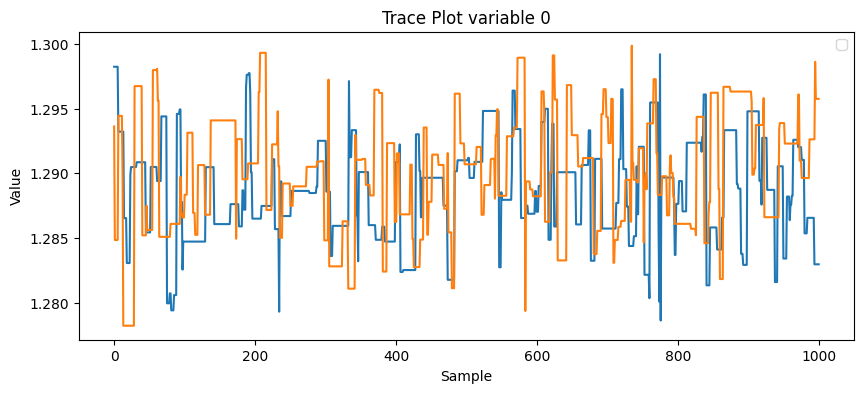

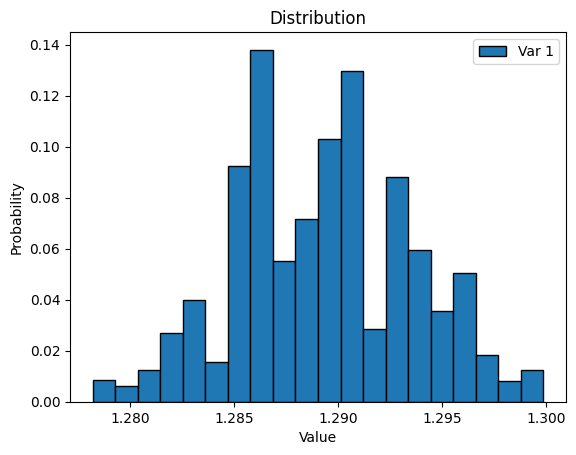

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 181.1116974898019


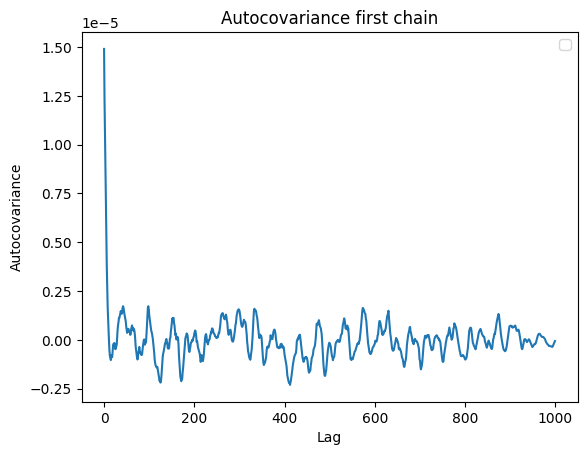

the difference between estimated values [8.71066473]



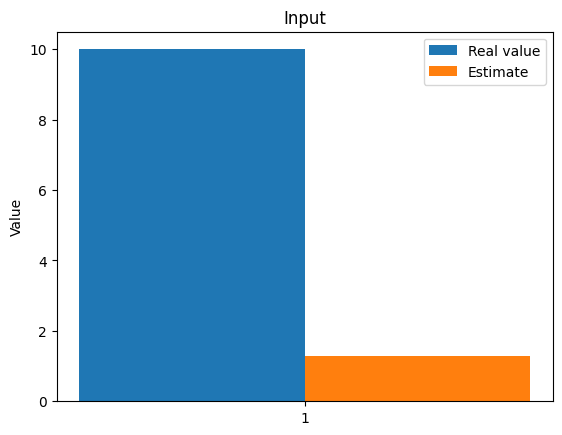

Sample 3000 / 3000

Average acceptance rate: 0.184 MCMC scale: 0.0465172674928844 

Mean values = [1.28915391]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.161 MCMC scale: 0.04616612391673677 

Mean values = [1.28936516]
(2, 1, 1000)


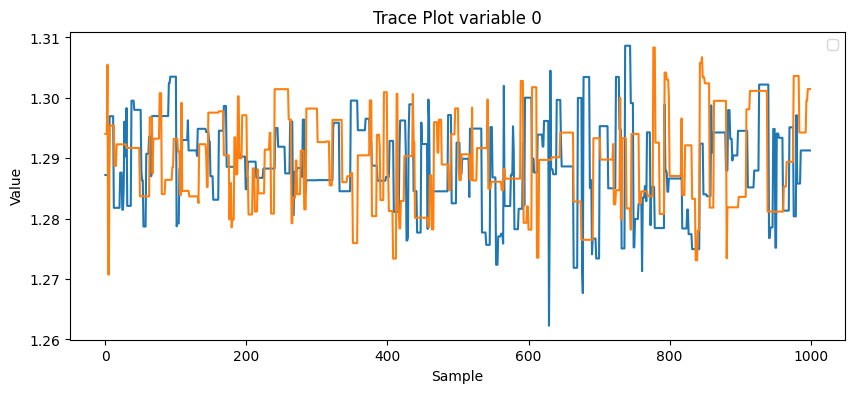

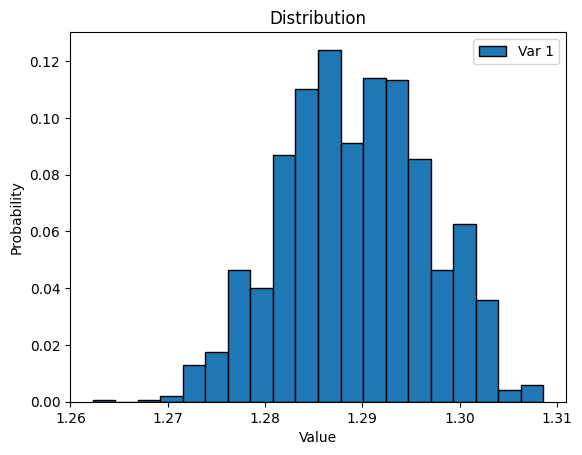

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 259.2910773669236


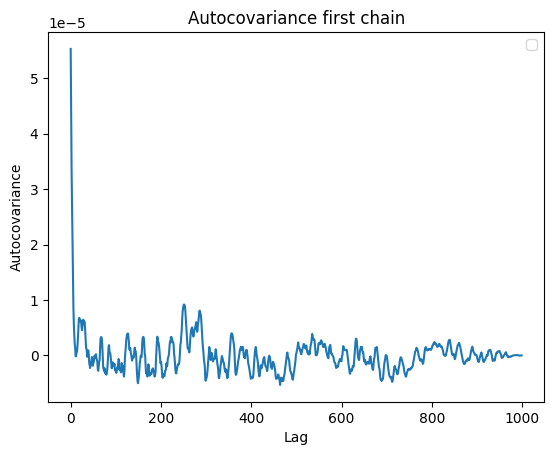

the difference between estimated values [8.71063484]



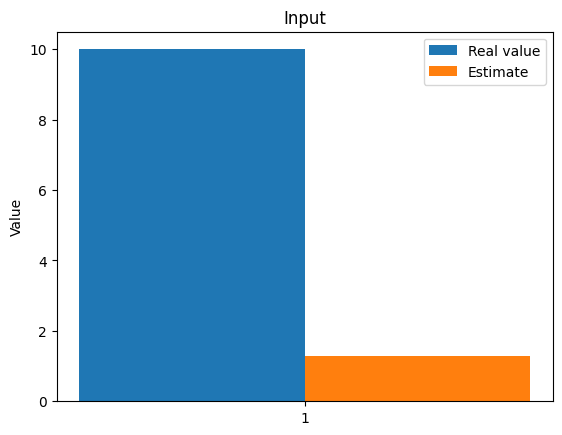

Sample 3000 / 3000

Average acceptance rate: 0.127 MCMC scale: 0.02825908805030382 

Mean values = [1.30209878]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.141 MCMC scale: 0.030123270239178348 

Mean values = [1.30223539]
(2, 1, 1000)


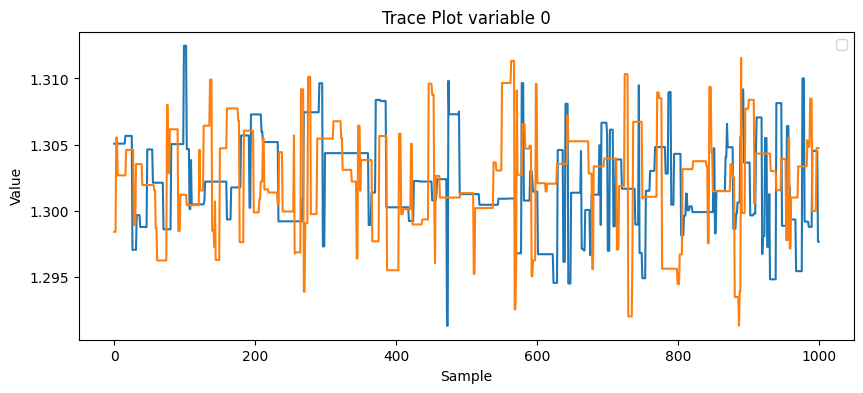

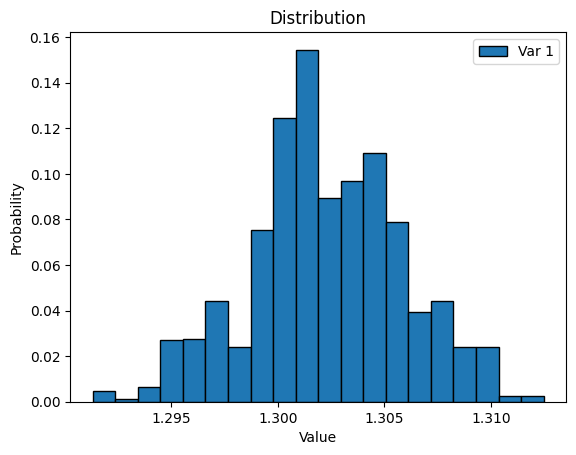

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 185.93820251456182


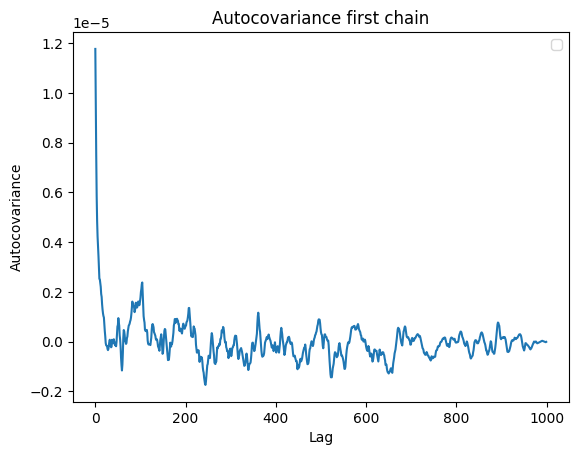

the difference between estimated values [8.69776461]



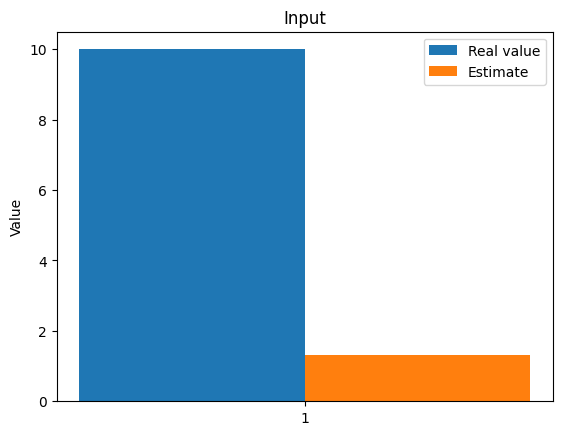

Sample 870 / 3000

KeyboardInterrupt: 

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([deltas[1]])
proposal_sd = [0.5,2.]
adapt = True
n_data = [50,30]

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 


In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = np.array([10, 20, 30, 40, 50])
sigma_noise = [0.1, 0.05]
n_data = [30, 50]
parameters = np.array([deltas[-1]])
sigma = np.array([2., 4.])
rwmh_scaling = np.array([0.5, 1., 2.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"


estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)




In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([deltas[-1]])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 
